In [1]:
import torch
from pathlib import Path
import sys

root_dir = Path('/home/eungyeop/LLM/tabular/ProtoLLM_entropic20251217')
sys.path.append(str(root_dir))

from models.TabularFLM_S_ import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed
from ot.batch import solve_gromov_batch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpt_path = '/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records_till_20260317/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-XTFORMER_EVALUATION100/50/20260225_221853/best_joint.pt'
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id='viz',
    mode='viz'
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print('Missing keys:', missing)
print('Unexpected keys:', unexpected)

model.eval()

/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph()
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x ModuleList(
        (0-1): 2 x lightGraphNeuralNet(
          (dropout): Dropout(p=0.1, inplace=False)
          (linear): Linear(in_features=768, out_features=192, bias=True)
          (update): Linear(in_features=192, out_features=768, bias=True)
          (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (attn): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): Tanh()
          (2): Linear(in_features=192, out_features=1, bias=True)
        )
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
 

In [2]:
args2 = args
fix_seed(args2.random_seed)

sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f'Loading dataloader for source: {src}')
    res = prepare_embedding_dataloaders(args2, src, is_source=True)
    tr, va, te = res['loaders']

    from torch.utils.data import ConcatDataset, DataLoader
    datasets = [l.dataset for l in [tr, va, te] if l is not None]
    ds = ConcatDataset(datasets)

    loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)

>>> [System] Seed 50 FIXED. Deterministic algorithms ENABLED.
Loading dataloader for source: Medicaldataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Medicaldataset.pkl
>>> [DataLoader] Created isolated generator with seed 50
[Source] Training data size: 1121
[Source] Validation data size: 198
Loading dataloader for source: Cardiovascular_Disease_Dataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
>>> [DataLoader] Created isolated generator with seed 50
[Source] Training data size: 850
[Source] Validation data size: 150
Loading dataloader for source: Heart_disease_statlog
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
>>> [DataLoader] Created isolated generator with seed 50
[Source] Training data size: 229
[Source] Va

In [3]:
import numpy as np
import pandas as pd
import torch.nn.functional as F

base_table_path = '/storage/personal/eungyeop/dataset/table/origin_table'

dataset_and_class = {
    'heart': ['target_binary', ['no','yes']],
    'Cardiovascular_Disease_Dataset': ['target_binary', ['no', 'yes']],
    'Medicaldataset': ['target_binary', ['no', 'yes']],
    'Heart_disease_statlog': ['target_binary', ['no','yes']],
    'Erbil_Cardiovascular_Health_Dataset': ['target_binary', ['no','yes']],
    'cardio_SAheart': ['target_binary', ['no','yes']],
    'heart_failure_clinical_records': ['target_binary', ['no','yes']],
}

label_col_map = {
    'Cardiovascular_Disease_Dataset': 'target',
    'Medicaldataset': 'Result',
    'heart1': 'output',
}

def load_original_tabular(dataset_name):
    csv_path = f'{base_table_path}/{dataset_name}.csv'
    df = pd.read_csv(csv_path)
    class_info = dataset_and_class.get(dataset_name)
    if class_info is None:
        for col in ['target_binary', 'target', 'Result', 'output', 'target_multiclass']:
            if col in df.columns:
                y = df[col]; X = df.drop(col, axis=1)
                return X.reset_index(drop=True), y.reset_index(drop=True)
        raise ValueError(f'Cannot find label column for {dataset_name}')
    class_name = class_info[0]
    if dataset_name in label_col_map:
        orig_col = label_col_map[dataset_name]
        if orig_col in df.columns:
            df[class_name] = df[orig_col]; df = df.drop(orig_col, axis=1)
    if class_name in df.columns:
        X = df.drop(class_name, axis=1); y = df[class_name]
    else:
        raise ValueError(f"Label column '{class_name}' not found")
    return X.reset_index(drop=True), y.reset_index(drop=True)


@torch.no_grad()
def compute_onehot_basis_risk(model, device):
    model.eval()
    lcg_feat, lcg_struct = model.latent_graph()
    M = lcg_feat.shape[0]
    expert_outputs = model.gnn_experts(lcg_feat.unsqueeze(0), lcg_struct.unsqueeze(0))

    onehot_probs = []
    for k in range(M):
        pi_onehot = torch.zeros(1, M, device=device)
        pi_onehot[0, k] = 1.0
        weighted = (pi_onehot.unsqueeze(-1) * expert_outputs).sum(dim=1)
        current_mode = getattr(model, 'mode', 'Full')
        logit = model.ghead2(weighted) if current_mode == 'Few' else model.ghead(weighted)
        onehot_probs.append(torch.sigmoid(logit).item())

    print('One-Hot Basis Risk:')
    for k in range(M):
        label = 'HIGH' if onehot_probs[k] > 0.5 else 'LOW'
        print(f'  B{k}: {onehot_probs[k]:.4f} -> {label}')
    return np.array(onehot_probs)


@torch.no_grad()
def extract_tp_tn_with_tabular(model, loader, device, dataset_name):
    model.eval()
    X_orig, y_orig = load_original_tabular(dataset_name)
    all_pi, all_y, all_prob, all_sidx = [], [], [], []

    for batch in loader:
        batch_t = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        out = model.predict(batch_t, return_all=True)
        global_pred = out[0] if isinstance(out, tuple) else out
        pi = model.graph_quantizer.last_pi
        prob = torch.sigmoid(global_pred).squeeze(-1)
        all_pi.append(pi.cpu().numpy())
        all_y.append(batch_t['y'].cpu().view(-1).numpy())
        all_prob.append(prob.cpu().view(-1).numpy())
        if 's_idx' in batch_t:
            sidx = batch_t['s_idx']
            if isinstance(sidx, torch.Tensor): all_sidx.append(sidx.cpu().view(-1).numpy())
            else: all_sidx.append(np.array([sidx] * pi.shape[0]))
        else:
            start = sum(len(s) for s in all_sidx)
            all_sidx.append(np.arange(start, start + pi.shape[0]))

    pis = np.concatenate(all_pi); ys = np.concatenate(all_y).astype(int)
    probs = np.concatenate(all_prob); sidxs = np.concatenate(all_sidx).astype(int)
    preds = (probs >= 0.5).astype(int)
    valid = sidxs < len(X_orig)
    if not valid.all():
        pis, ys, probs, sidxs, preds = pis[valid], ys[valid], probs[valid], sidxs[valid], preds[valid]

    tp = (ys == 1) & (preds == 1); tn = (ys == 0) & (preds == 0)
    fp = (ys == 0) & (preds == 1); fn = (ys == 1) & (preds == 0)
    X_mapped = X_orig.iloc[sidxs].reset_index(drop=True)

    print(f'[{dataset_name}] N={len(ys)}, TP={tp.sum()}, TN={tn.sum()}, FP={fp.sum()}, FN={fn.sum()}')
    return {'dataset_name': dataset_name, 'X': X_mapped, 'pis': pis, 'ys': ys,
            'probs': probs, 'preds': preds, 'argmax': pis.argmax(axis=1),
            'tp_mask': tp, 'tn_mask': tn, 'fp_mask': fp, 'fn_mask': fn}

## Build `onehot_probs` and `all_results`

In [4]:
onehot_probs = compute_onehot_basis_risk(model, device)

all_results = {}
for src_name in sources:
    all_results[src_name] = extract_tp_tn_with_tabular(model, loaders[src_name], device, src_name)

One-Hot Basis Risk:
  B0: 0.0240 -> LOW
  B1: 0.9376 -> HIGH
  B2: 0.8102 -> HIGH
  B3: 0.2489 -> LOW
  B4: 0.4552 -> LOW
  B5: 0.0379 -> LOW
  B6: 0.8174 -> HIGH
  B7: 0.9943 -> HIGH
[Medicaldataset] N=1319, TP=611, TN=382, FP=127, FN=199
[Cardiovascular_Disease_Dataset] N=1000, TP=545, TN=134, FP=286, FN=35
[Heart_disease_statlog] N=270, TP=82, TN=91, FP=59, FN=38
[Erbil_Cardiovascular_Health_Dataset] N=287, TP=95, TN=174, FP=11, FN=7
[cardio_SAheart] N=462, TP=82, TN=211, FP=91, FN=78
[heart_failure_clinical_records] N=299, TP=75, TN=171, FP=32, FN=21


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, chi2_contingency
from sklearn.preprocessing import StandardScaler

EXCLUDE_FEATURES = {'patientid', 'patient_id', 'id', 'ID', 'time'}

BASIS_COLORS = {
    'B0': '#377eb8', 'B1': '#e41a1c', 'B2': '#ff7f00', 'B3': '#4daf4a',
    'B4': '#67a9cf', 'B5': '#984ea3', 'B6': '#f781bf', 'B7': '#a65628',
}

def detect_feature_types(X):
    """Detect numerical vs categorical features."""
    num_cols = []
    cat_cols = []
    for col in X.columns:
        if col.lower() in {f.lower() for f in EXCLUDE_FEATURES}:
            continue
        if X[col].dtype in ['object', 'category']:
            cat_cols.append(col)
        elif X[col].nunique() <= 5:
            cat_cols.append(col)
        else:
            num_cols.append(col)
    return num_cols, cat_cols


def compute_pvalue_profile(X, argmax, basis_k, num_cols, cat_cols):
    """Compute -log10(p) for basis_k vs rest, for all features."""
    in_group = (argmax == basis_k)
    out_group = ~in_group

    if in_group.sum() < 3 or out_group.sum() < 3:
        return None, None

    features = []
    scores = []
    ftypes = []

    for col in num_cols:
        vals_in = X.loc[in_group, col].dropna()
        vals_out = X.loc[out_group, col].dropna()
        if len(vals_in) < 2 or len(vals_out) < 2:
            continue
        try:
            _, p = ttest_ind(vals_in, vals_out, equal_var=False)
            if p < 1e-300:
                p = 1e-300
            score = -np.log10(p)
            features.append(col)
            scores.append(score)
            ftypes.append('num')
        except:
            continue

    for col in cat_cols:
        try:
            ct = pd.crosstab(in_group, X[col])
            if ct.shape[0] < 2 or ct.shape[1] < 2:
                continue
            chi2, p, dof, expected = chi2_contingency(ct)
            if p < 1e-300:
                p = 1e-300
            score = -np.log10(p)
            features.append(col)
            scores.append(score)
            ftypes.append('cat')
        except:
            continue

    return features, scores, ftypes


def plot_radar_pvalue(result, onehot_probs, ax, min_n=5, max_features=12):
    """Radar chart: -log10(p) min-max normalized within dataset."""
    src_name = result['dataset_name']
    X = result['X']
    argmax = result['argmax']
    ys = result['ys']
    M = result['pis'].shape[1]
    short_name = src_name.replace('_Dataset', '').replace('_clinical_records', '').replace('_Health_Dataset', '')

    num_cols, cat_cols = detect_feature_types(X)

    high_risk_bases = [k for k in range(M) if onehot_probs[k] > 0.5]
    low_risk_bases = [k for k in range(M) if onehot_probs[k] <= 0.5]

    # Active bases with enough samples
    active_h = []
    for k in high_risk_bases:
        n = (argmax == k).sum()
        if n >= min_n:
            active_h.append((k, int(n)))
    active_h.sort(key=lambda x: -x[1])
    active_h = active_h[:5]

    tn_ref = None
    best_tn_n = 0
    for k in low_risk_bases:
        n = (argmax == k).sum()
        if n >= min_n and n > best_tn_n:
            tn_ref = k
            best_tn_n = int(n)

    draw_list = []
    if tn_ref is not None:
        draw_list.append((tn_ref, 'tn_ref', best_tn_n))
    for k, n in active_h:
        draw_list.append((k, 'high', n))

    if not draw_list:
        ax.text(0.5, 0.5, f'[{short_name}]\nNo active bases',
                ha='center', va='center', transform=ax.transAxes)
        return

    # Compute profiles for all active bases
    all_profiles = {}
    all_feature_sets = set()
    all_ftypes_map = {}

    for k, kind, n in draw_list:
        result_pv = compute_pvalue_profile(X, argmax, k, num_cols, cat_cols)
        if result_pv is None or result_pv[0] is None:
            continue
        features, scores, ftypes = result_pv
        all_profiles[k] = dict(zip(features, scores))
        all_feature_sets.update(features)
        for f, ft in zip(features, ftypes):
            all_ftypes_map[f] = ft

    if not all_profiles or not all_feature_sets:
        ax.text(0.5, 0.5, f'[{short_name}]\nNo significant features',
                ha='center', va='center', transform=ax.transAxes)
        return

    # Select top features by max score across bases
    feature_max_scores = {}
    for f in all_feature_sets:
        feature_max_scores[f] = max(prof.get(f, 0) for prof in all_profiles.values())
    top_features = sorted(feature_max_scores.keys(), key=lambda f: -feature_max_scores[f])[:max_features]

    if len(top_features) < 3:
        ax.text(0.5, 0.5, f'[{short_name}]\nToo few features',
                ha='center', va='center', transform=ax.transAxes)
        return

    # Build score matrix and min-max normalize within this dataset
    score_matrix = np.zeros((len(draw_list), len(top_features)))
    valid_bases = []
    for i, (k, kind, n) in enumerate(draw_list):
        if k not in all_profiles:
            continue
        valid_bases.append(i)
        for j, f in enumerate(top_features):
            score_matrix[i, j] = all_profiles[k].get(f, 0)

    # Cap at 95th percentile, then divide by cap, then sqrt
    all_vals = score_matrix[valid_bases].flatten()
    cap_val = np.percentile(all_vals, 95)
    if cap_val < 1.0:
        cap_val = all_vals.max()
    if cap_val < 1e-9:
        score_matrix = np.zeros_like(score_matrix)
    else:
        score_matrix = np.sqrt(np.clip(score_matrix, 0, cap_val) / cap_val)

    # Draw radar
    n_features = len(top_features)
    angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
    angles += angles[:1]

    for i, (k, kind, n) in enumerate(draw_list):
        if i not in valid_bases:
            continue

        color = BASIS_COLORS.get(f'B{k}', '#999999')
        values = score_matrix[i].tolist()
        values += values[:1]

        if kind == 'tn_ref':
            linestyle, linewidth, alpha_fill = '--', 2.0, 0.05
            risk_label = 'L'
            tag = f'TN n={n}'
        else:
            linestyle, linewidth, alpha_fill = '-', 2.5, 0.15
            risk_label = 'H'
            tag = f'n={n}'

        ax.plot(angles, values, color=color, linewidth=linewidth,
                linestyle=linestyle, label=f'B{k} [{risk_label}] ({tag})')
        ax.fill(angles, values, color=color, alpha=alpha_fill)

    # Feature labels with type annotation
    labels = []
    label_colors = []
    for f in top_features:
        ftype = all_ftypes_map.get(f, 'num')
        labels.append(f'{f}\n({ftype})')
        if ftype == 'cat':
            label_colors.append('#2ca02c')  # green for categorical
        else:
            label_colors.append('#333333')  # dark for numerical

    ax.set_xticks(angles[:-1])
    tick_labels = ax.set_xticklabels(labels, fontsize=7)
    for label, color in zip(tick_labels, label_colors):
        label.set_color(color)

    ax.set_ylim(0, 1.1)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0', '0.25', '0.5', '0.75', '1.0'], fontsize=6, color='gray')

    ax.legend(fontsize=6, loc='upper right', bbox_to_anchor=(1.35, 1.1))
    ax.set_title(f'{short_name}', fontsize=10, pad=15)


def save_radar_pvalue_combined(all_results, onehot_probs, sources, save_path=None):
    """Draw two 1x3 radar figures."""
    n_per_row = 3
    n_figs = (len(sources) + n_per_row - 1) // n_per_row

    figs = []
    for fig_idx in range(n_figs):
        start = fig_idx * n_per_row
        end = min(start + n_per_row, len(sources))
        batch = sources[start:end]
        n = len(batch)

        fig, axes = plt.subplots(1, n, figsize=(7 * n, 7), subplot_kw=dict(polar=True))
        if n == 1:
            axes = [axes]
        for i, src in enumerate(batch):
            if src in all_results:
                plot_radar_pvalue(all_results[src], onehot_probs, axes[i])
        plt.tight_layout()

        if save_path:
            base, ext = os.path.splitext(save_path)
            path = f'{base}_part{fig_idx+1}{ext}'
            fig.savefig(path, dpi=150, bbox_inches='tight')
            plt.close(fig)
        else:
            plt.show()
        figs.append(fig)
    return figs


def save_radar_pvalue_individual(all_results, onehot_probs, sources, save_dir):
    """Draw individual radar per source."""
    import os
    os.makedirs(save_dir, exist_ok=True)
    for src in sources:
        if src not in all_results:
            continue
        fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw=dict(polar=True))
        plot_radar_pvalue(all_results[src], onehot_probs, ax)
        short = src.replace('_Dataset', '').replace('_clinical_records', '').replace('_Health_Dataset', '')
        fig.savefig(os.path.join(save_dir, f'radar_pval_{short}.png'), dpi=150, bbox_inches='tight')
        plt.close(fig)

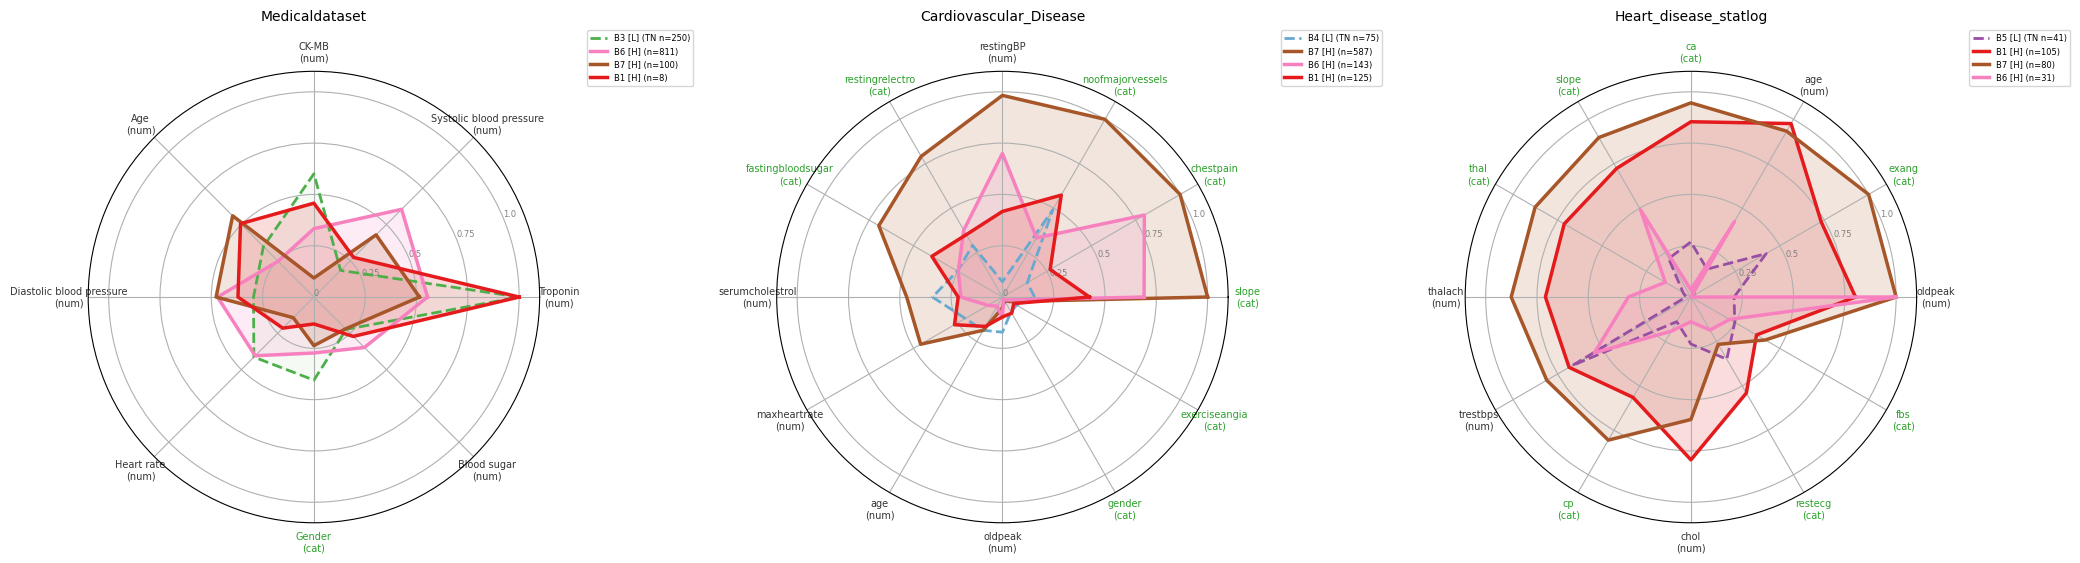

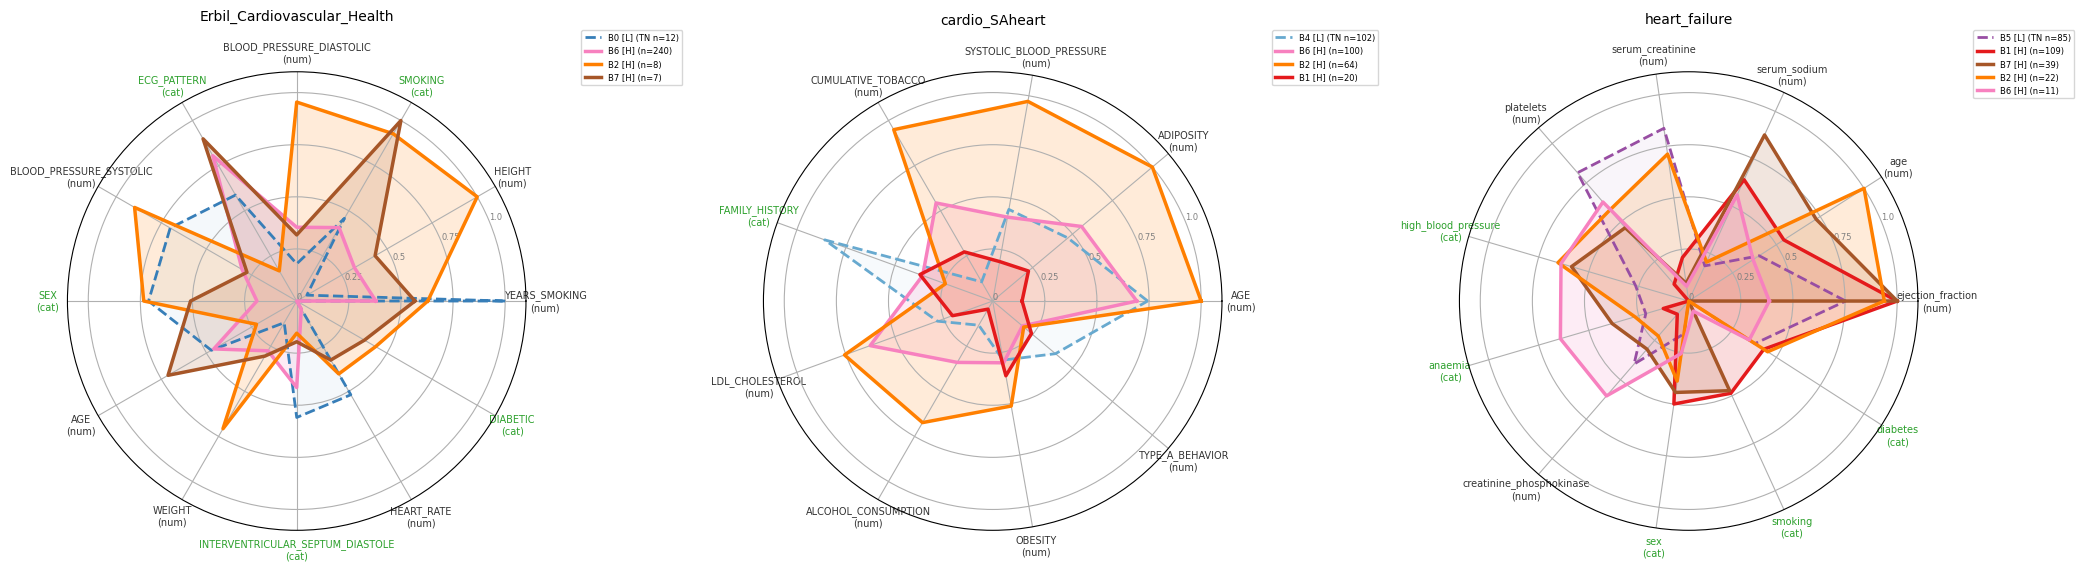

[<Figure size 2100x700 with 3 Axes>, <Figure size 2100x700 with 3 Axes>]

In [8]:
# 위의 radar_pvalue.py 내용을 셀에 붙여넣거나 import 후:

save_radar_pvalue_combined(all_results, onehot_probs, sources)

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, chi2_contingency

EXCLUDE_FEATURES = {'patientid', 'patient_id', 'id', 'ID', 'time'}

BASIS_COLORS = {
    'B0': '#377eb8', 'B1': '#e41a1c', 'B2': '#ff7f00', 'B3': '#4daf4a',
    'B4': '#67a9cf', 'B5': '#984ea3', 'B6': '#f781bf', 'B7': '#a65628',
}

def detect_ftypes_v2(X):
    num_cols, cat_cols = [], []
    for col in X.columns:
        if col.lower() in {f.lower() for f in EXCLUDE_FEATURES}:
            continue
        if X[col].dtype in ['object', 'category'] or X[col].nunique() <= 5:
            cat_cols.append(col)
        else:
            num_cols.append(col)
    return num_cols, cat_cols


def compute_pval_profile_v2(X, argmax, basis_k, num_cols, cat_cols):
    in_group = (argmax == basis_k)
    out_group = ~in_group
    if in_group.sum() < 3 or out_group.sum() < 3:
        return None, None, None
    features, scores, ftypes = [], [], []
    for col in num_cols:
        vals_in = X.loc[in_group, col].dropna()
        vals_out = X.loc[out_group, col].dropna()
        if len(vals_in) < 2 or len(vals_out) < 2:
            continue
        try:
            _, p = ttest_ind(vals_in, vals_out, equal_var=False)
            if p < 1e-300: p = 1e-300
            features.append(col); scores.append(-np.log10(p)); ftypes.append('num')
        except:
            continue
    for col in cat_cols:
        try:
            ct = pd.crosstab(in_group, X[col])
            if ct.shape[0] < 2 or ct.shape[1] < 2: continue
            _, p, _, _ = chi2_contingency(ct)
            if p < 1e-300: p = 1e-300
            features.append(col); scores.append(-np.log10(p)); ftypes.append('cat')
        except:
            continue
    return features, scores, ftypes


def plot_radar_pval_v2(result, onehot_probs, ax, min_n=5, max_features=12):
    src_name = result['dataset_name']
    X = result['X']
    argmax = result['argmax']
    ys = result['ys']
    M = result['pis'].shape[1]
    short_name = src_name.replace('_Dataset', '').replace('_clinical_records', '').replace('_Health_Dataset', '')

    num_cols, cat_cols = detect_ftypes_v2(X)

    high_risk_bases = [k for k in range(M) if onehot_probs[k] > 0.5]
    low_risk_bases = [k for k in range(M) if onehot_probs[k] <= 0.5]

    active_h = []
    for k in high_risk_bases:
        n = (argmax == k).sum()
        if n >= min_n:
            active_h.append((k, int(n)))
    active_h.sort(key=lambda x: -x[1])
    active_h = active_h[:5]

    tn_ref, best_tn_n = None, 0
    for k in low_risk_bases:
        n = (argmax == k).sum()
        if n >= min_n and n > best_tn_n:
            tn_ref, best_tn_n = k, int(n)

    draw_list = []
    if tn_ref is not None:
        draw_list.append((tn_ref, 'tn_ref', best_tn_n))
    for k, n in active_h:
        draw_list.append((k, 'high', n))

    if not draw_list:
        ax.text(0.5, 0.5, f'[{short_name}]\nNo active bases', ha='center', va='center', transform=ax.transAxes)
        return

    all_profiles, all_feature_sets, all_ftypes_map = {}, set(), {}
    for k, kind, n in draw_list:
        res = compute_pval_profile_v2(X, argmax, k, num_cols, cat_cols)
        if res[0] is None: continue
        features, scores, ftypes = res
        all_profiles[k] = dict(zip(features, scores))
        all_feature_sets.update(features)
        for f, ft in zip(features, ftypes):
            all_ftypes_map[f] = ft

    if not all_profiles or not all_feature_sets:
        ax.text(0.5, 0.5, f'[{short_name}]\nNo significant features', ha='center', va='center', transform=ax.transAxes)
        return

    feature_max_scores = {f: max(p.get(f, 0) for p in all_profiles.values()) for f in all_feature_sets}
    top_features = sorted(feature_max_scores, key=lambda f: -feature_max_scores[f])[:max_features]

    if len(top_features) < 3:
        ax.text(0.5, 0.5, f'[{short_name}]\nToo few features', ha='center', va='center', transform=ax.transAxes)
        return

    score_matrix = np.zeros((len(draw_list), len(top_features)))
    valid_bases = []
    for i, (k, kind, n) in enumerate(draw_list):
        if k not in all_profiles: continue
        valid_bases.append(i)
        for j, f in enumerate(top_features):
            score_matrix[i, j] = all_profiles[k].get(f, 0)

    # Cap at 95th percentile, divide by cap, sqrt
    all_vals = score_matrix[valid_bases].flatten()
    cap_val = np.percentile(all_vals, 95)
    if cap_val < 1.0: cap_val = all_vals.max()
    if cap_val < 1e-9:
        score_matrix = np.zeros_like(score_matrix)
    else:
        score_matrix = np.sqrt(np.clip(score_matrix, 0, cap_val) / cap_val)

    # Draw
    n_features = len(top_features)
    angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
    angles += angles[:1]

    for i, (k, kind, n) in enumerate(draw_list):
        if i not in valid_bases: continue
        color = BASIS_COLORS.get(f'B{k}', '#999999')
        values = score_matrix[i].tolist() + [score_matrix[i, 0]]

        if kind == 'tn_ref':
            ls, lw, af = '--', 2.0, 0.05
            label = f'B{k} [L] (TN n={n})'
        else:
            ls, lw, af = '-', 2.5, 0.15
            label = f'B{k} [H] (n={n})'

        ax.plot(angles, values, color=color, linewidth=lw, linestyle=ls, label=label)
        ax.fill(angles, values, color=color, alpha=af)

    # Feature labels with direction
    labels, label_colors = [], []
    pos_mask = (ys == 1)
    for f in top_features:
        ftype = all_ftypes_map.get(f, 'num')
        if ftype == 'num':
            pos_mean = X.loc[pos_mask, f].mean()
            all_mean = X[f].mean()
            arrow = '↑' if pos_mean > all_mean else '↓'
            labels.append(f'{f}\n(num {arrow})')
            label_colors.append('#e41a1c' if pos_mean > all_mean else '#377eb8')
        else:
            pos_vals = X.loc[pos_mask, f].dropna()
            if len(pos_vals) > 0:
                mode_val = pos_vals.mode().iloc[0]
                mode_pct = (pos_vals == mode_val).mean() * 100
                labels.append(f'{f}\n(cat: {mode_val} {mode_pct:.0f}%)')
            else:
                labels.append(f'{f}\n(cat)')
            label_colors.append('#2ca02c')

    ax.set_xticks(angles[:-1])
    tick_labels = ax.set_xticklabels(labels, fontsize=7)
    for lbl, clr in zip(tick_labels, label_colors):
        lbl.set_color(clr)

    ax.set_ylim(0, 1.1)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0', '0.25', '0.5', '0.75', '1.0'], fontsize=6, color='gray')
    ax.legend(fontsize=6, loc='upper right', bbox_to_anchor=(1.35, 1.1))
    ax.set_title(f'{short_name}', fontsize=10, pad=15)


def save_radar_pval_v2_combined(all_results, onehot_probs, sources, save_path=None):
    n_per_row = 3
    n_figs = (len(sources) + n_per_row - 1) // n_per_row
    for fig_idx in range(n_figs):
        start = fig_idx * n_per_row
        end = min(start + n_per_row, len(sources))
        batch = sources[start:end]
        n = len(batch)
        fig, axes = plt.subplots(1, n, figsize=(7 * n, 7), subplot_kw=dict(polar=True))
        if n == 1: axes = [axes]
        for i, src in enumerate(batch):
            if src in all_results:
                plot_radar_pval_v2(all_results[src], onehot_probs, axes[i])
        plt.tight_layout()
        if save_path:
            base, ext = os.path.splitext(save_path)
            fig.savefig(f'{base}_part{fig_idx+1}{ext}', dpi=150, bbox_inches='tight')
            plt.close(fig)
        else:
            plt.show()

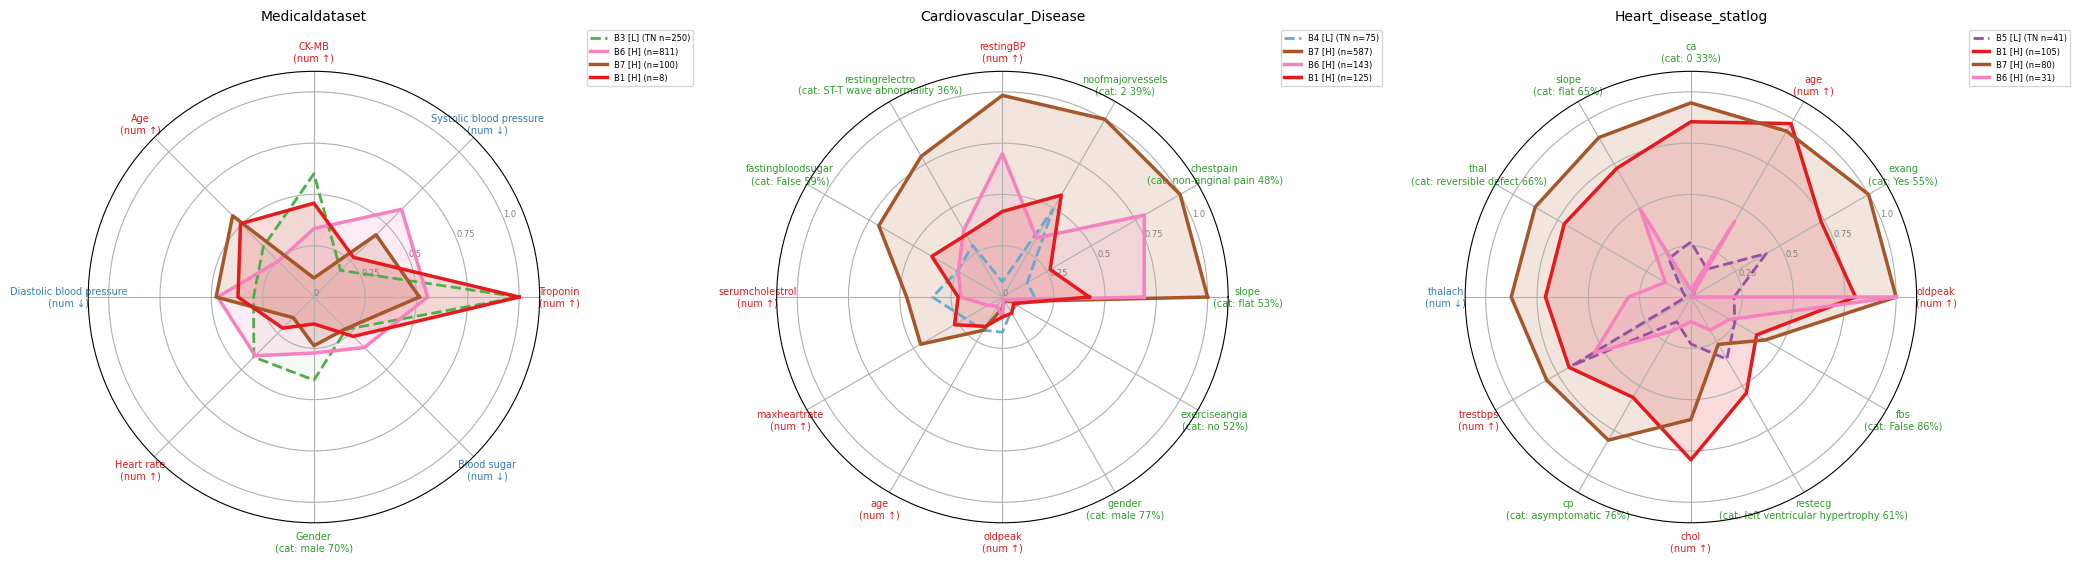

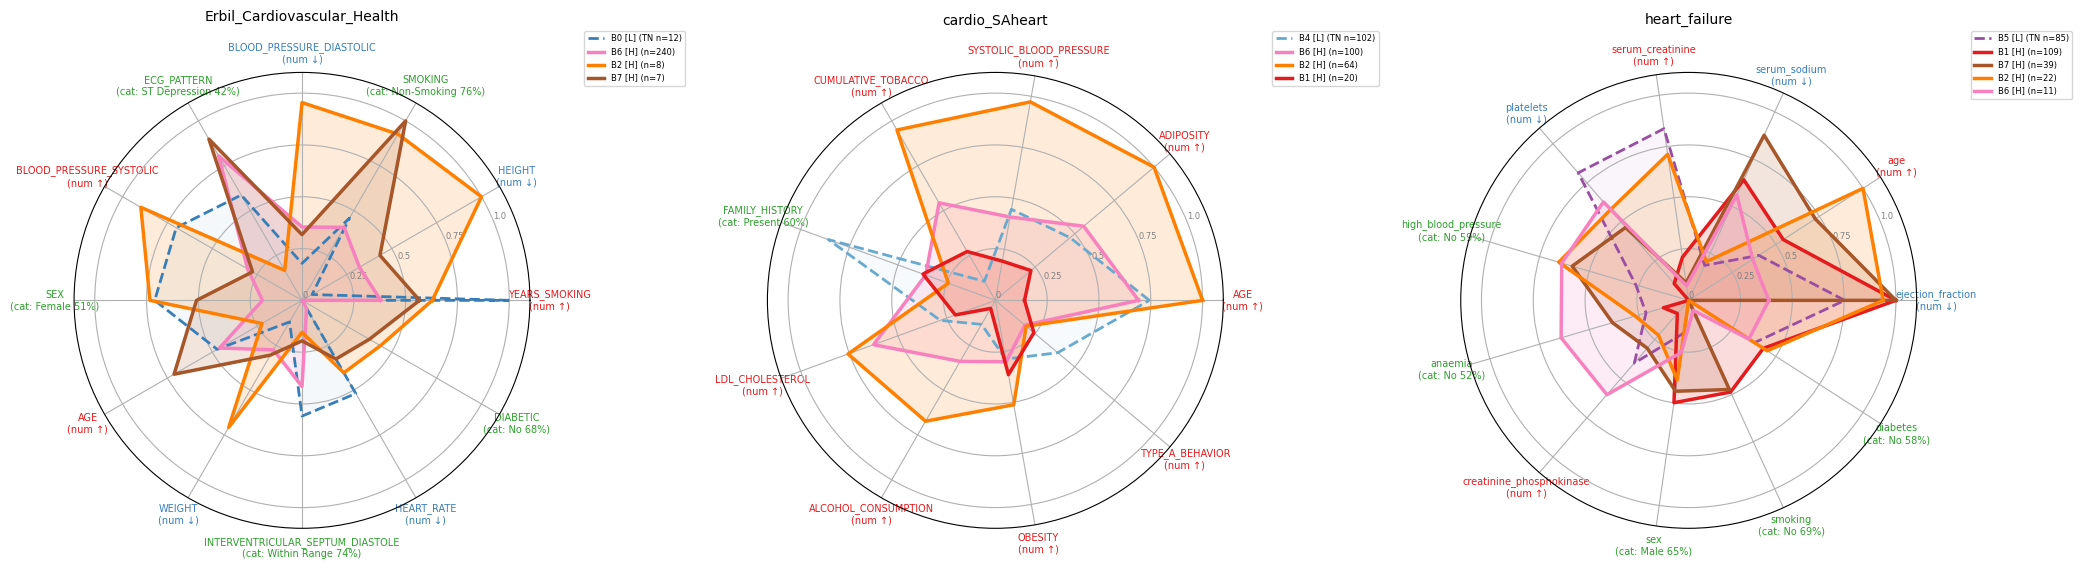

In [13]:
save_radar_pval_v2_combined(all_results, onehot_probs, sources)

In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, chi2_contingency

DATASET_SHORT_NAMES = {
    'Medicaldataset': 'MED (CAD)',
    'Cardiovascular_Disease_Dataset': 'CDD (CAD)',
    'heart': 'HD (CAD)',
    'Heart_disease_statlog': 'HD_S (CAD)',
    'Erbil_Cardiovascular_Health_Dataset': 'ERB (CVD)',
    'cardio_SAheart': 'SAH (CHD)',
    'heart_failure_clinical_records': 'HF (MRT)',
}

# Clinical risk direction: ↑ = higher is risky, ↓ = lower is risky
RISK_DIRECTION = {
    # Blood pressure
    'systolic blood pressure': '↑', 'Systolic blood pressure': '↑',
    'SYSTOLIC_BLOOD_PRESSURE': '↑', 'BLOOD_PRESSURE_SYSTOLIC': '↑',
    'diastolic blood pressure': '↑', 'Diastolic blood pressure': '↑',
    'BLOOD_PRESSURE_DIASTOLIC': '↑',
    'restingBP': '↑', 'trestbps': '↑', 'restingbp': '↑',
    # Cholesterol / lipids
    'serumcholestrol': '↑', 'cholesterol': '↑', 'Cholesterol': '↑',
    'chol': '↑', 'LDL_CHOLESTEROL': '↑',
    # Blood sugar
    'Blood sugar': '↑', 'blood_sugar': '↑',
    # Cardiac biomarkers
    'CK-MB': '↑', 'Troponin': '↑',
    'creatinine_phosphokinase': '↑',
    'serum_creatinine': '↑',
    # Age
    'Age': '↑', 'age': '↑', 'AGE': '↑',
    # Heart rate (resting = higher is risky)
    'Heart rate': '↑', 'HEART_RATE': '↑',
    # Max heart rate (lower is risky)
    'maxheartrate': '↓', 'thalach': '↓', 'maxHR': '↓',
    # Exercise / ST
    'oldpeak': '↑', 'Oldpeak': '↑',
    # Ejection fraction (lower is risky)
    'ejection_fraction': '↓',
    # Serum sodium (lower is risky)
    'serum_sodium': '↓',
    # Platelets (lower is risky in HF)
    'platelets': '↓',
    # Body composition
    'OBESITY': '↑', 'ADIPOSITY': '↑', 'WEIGHT': '↑', 'weight': '↑',
    'HEIGHT': '↑',
    # Smoking / tobacco
    'CUMULATIVE_TOBACCO': '↑', 'YEARS_SMOKING': '↑',
    # Hypertension
    'HYPERTENSION': '↑',
}

EXCLUDE_FEATURES = {'patientid', 'patient_id', 'id', 'ID', 'time'}

BASIS_COLORS = {
    'B0': '#377eb8', 'B1': '#e41a1c', 'B2': '#ff7f00', 'B3': '#4daf4a',
    'B4': '#67a9cf', 'B5': '#984ea3', 'B6': '#f781bf', 'B7': '#a65628',
}

def detect_ftypes_v3(X):
    num_cols, cat_cols = [], []
    for col in X.columns:
        if col.lower() in {f.lower() for f in EXCLUDE_FEATURES}:
            continue
        if X[col].dtype in ['object', 'category'] or X[col].nunique() <= 5:
            cat_cols.append(col)
        else:
            num_cols.append(col)
    return num_cols, cat_cols


def compute_signed_profile_v3(X, argmax, basis_k, num_cols, cat_cols):
    """Compute signed importance: +/-sqrt(-log10(p)/cap) for num, +sqrt for cat."""
    in_group = (argmax == basis_k)
    out_group = ~in_group
    if in_group.sum() < 3 or out_group.sum() < 3:
        return None, None, None, None

    features, raw_scores, signs, ftypes = [], [], [], []

    for col in num_cols:
        vals_in = X.loc[in_group, col].dropna()
        vals_out = X.loc[out_group, col].dropna()
        if len(vals_in) < 2 or len(vals_out) < 2:
            continue
        try:
            _, p = ttest_ind(vals_in, vals_out, equal_var=False)
            if p < 1e-300: p = 1e-300
            score = -np.log10(p)
            sign = 1.0 if vals_in.mean() > vals_out.mean() else -1.0
            features.append(col)
            raw_scores.append(score)
            signs.append(sign)
            ftypes.append('num')
        except:
            continue

    for col in cat_cols:
        try:
            ct = pd.crosstab(in_group, X[col])
            if ct.shape[0] < 2 or ct.shape[1] < 2: continue
            _, p, _, _ = chi2_contingency(ct)
            if p < 1e-300: p = 1e-300
            score = -np.log10(p)
            features.append(col)
            raw_scores.append(score)
            signs.append(1.0)  # categorical: always positive (outward)
            ftypes.append('cat')
        except:
            continue

    return features, raw_scores, signs, ftypes


def plot_radar_pval_v3(result, onehot_probs, ax, min_n=5, max_features=12):
    src_name = result['dataset_name']
    X = result['X']
    argmax = result['argmax']
    ys = result['ys']
    M = result['pis'].shape[1]
    short_name = DATASET_SHORT_NAMES.get(src_name, src_name)

    num_cols, cat_cols = detect_ftypes_v3(X)

    high_risk_bases = [k for k in range(M) if onehot_probs[k] > 0.5]
    low_risk_bases = [k for k in range(M) if onehot_probs[k] <= 0.5]

    active_h = []
    for k in high_risk_bases:
        n = (argmax == k).sum()
        if n >= min_n:
            active_h.append((k, int(n)))
    active_h.sort(key=lambda x: -x[1])
    active_h = active_h[:5]

    tn_ref, best_tn_n = None, 0
    for k in low_risk_bases:
        n = (argmax == k).sum()
        if n >= min_n and n > best_tn_n:
            tn_ref, best_tn_n = k, int(n)

    draw_list = []
    if tn_ref is not None:
        draw_list.append((tn_ref, 'tn_ref', best_tn_n))
    for k, n in active_h:
        draw_list.append((k, 'high', n))

    if not draw_list:
        ax.text(0.5, 0.5, f'[{short_name}]\nNo active bases', ha='center', va='center', transform=ax.transAxes)
        return

    # Collect profiles
    all_profiles = {}
    all_signs = {}
    all_feature_sets = set()
    all_ftypes_map = {}

    for k, kind, n in draw_list:
        res = compute_signed_profile_v3(X, argmax, k, num_cols, cat_cols)
        if res[0] is None: continue
        features, raw_scores, signs, ftypes = res
        all_profiles[k] = dict(zip(features, raw_scores))
        all_signs[k] = dict(zip(features, signs))
        all_feature_sets.update(features)
        for f, ft in zip(features, ftypes):
            all_ftypes_map[f] = ft

    if not all_profiles or not all_feature_sets:
        ax.text(0.5, 0.5, f'[{short_name}]\nNo significant features', ha='center', va='center', transform=ax.transAxes)
        return

    # Select top features by max raw score
    feature_max = {f: max(p.get(f, 0) for p in all_profiles.values()) for f in all_feature_sets}
    top_features = sorted(feature_max, key=lambda f: -feature_max[f])[:max_features]

    if len(top_features) < 3:
        ax.text(0.5, 0.5, f'[{short_name}]\nToo few features', ha='center', va='center', transform=ax.transAxes)
        return

    # Build raw score matrix
    raw_matrix = np.zeros((len(draw_list), len(top_features)))
    sign_matrix = np.ones((len(draw_list), len(top_features)))
    valid_bases = []
    for i, (k, kind, n) in enumerate(draw_list):
        if k not in all_profiles: continue
        valid_bases.append(i)
        for j, f in enumerate(top_features):
            raw_matrix[i, j] = all_profiles[k].get(f, 0)
            sign_matrix[i, j] = all_signs[k].get(f, 1.0)

    # Cap + sqrt normalize (unsigned)
    all_vals = raw_matrix[valid_bases].flatten()
    cap_val = np.percentile(all_vals, 95)
    if cap_val < 1.0: cap_val = all_vals.max()
    if cap_val < 1e-9:
        norm_matrix = np.zeros_like(raw_matrix)
    else:
        norm_matrix = np.sqrt(np.clip(raw_matrix, 0, cap_val) / cap_val)

    # Apply sign: positive = outward, negative = inward
    signed_matrix = norm_matrix * sign_matrix

    # Draw radar
    n_features = len(top_features)
    angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
    angles += angles[:1]

    for i, (k, kind, n) in enumerate(draw_list):
        if i not in valid_bases: continue
        color = BASIS_COLORS.get(f'B{k}', '#999999')
        values = signed_matrix[i].tolist() + [signed_matrix[i, 0]]

        if kind == 'tn_ref':
            ls, lw, af = '--', 2.0, 0.05
            label = f'B{k} [L] (TN n={n})'
        else:
            ls, lw, af = '-', 2.5, 0.15
            label = f'B{k} [H] (n={n})'

        ax.plot(angles, values, color=color, linewidth=lw, linestyle=ls, label=label)
        ax.fill(angles, values, color=color, alpha=af)

    # Feature labels: unified format
    labels = []
    pos_mask = (ys == 1)
    for f in top_features:
        ftype = all_ftypes_map.get(f, 'num')
        if ftype == 'num':
            arrow = RISK_DIRECTION.get(f, '?')
            labels.append(f'{f}\n[Num {arrow}]')
        else:
            pos_vals = X.loc[pos_mask, f].dropna()
            if len(pos_vals) > 0:
                mode_val = pos_vals.mode().iloc[0]
                mode_pct = (pos_vals == mode_val).mean() * 100
                labels.append(f'{f}\n[Cat: {mode_val} {mode_pct:.0f}%]')
            else:
                labels.append(f'{f}\n[Cat]')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9, color='black')
    ax.tick_params(axis='x', pad=20)

    # Y-axis: -1 to +1, 0 as clear baseline
    ax.set_ylim(-1.1, 1.1)
    ax.set_yticks([-1.0, -0.5, 0, 0.5, 1.0])
    ax.set_yticklabels(['-1.0\n(lower)', '-0.5', '0\n(avg)', '0.5', '1.0\n(higher)'],
                       fontsize=6, color='gray')

    # Bold zero line
    zero_angles = np.linspace(0, 2 * np.pi, 100)
    ax.plot(zero_angles, [0] * 100, color='black', linewidth=1.0, linestyle='-', alpha=0.4)

    ax.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.4, 1.1))
    ax.set_title(f'{short_name}', fontsize=12, pad=20)


def save_radar_pval_v3_combined(all_results, onehot_probs, sources, save_path=None):
    n_per_row = 3
    n_figs = (len(sources) + n_per_row - 1) // n_per_row
    for fig_idx in range(n_figs):
        start = fig_idx * n_per_row
        end = min(start + n_per_row, len(sources))
        batch = sources[start:end]
        n = len(batch)
        fig, axes = plt.subplots(1, n, figsize=(7 * n, 7), subplot_kw=dict(polar=True))
        if n == 1: axes = [axes]
        for i, src in enumerate(batch):
            if src in all_results:
                plot_radar_pval_v3(all_results[src], onehot_probs, axes[i])
        plt.tight_layout()
        if save_path:
            base, ext = os.path.splitext(save_path)
            fig.savefig(f'{base}_part{fig_idx+1}{ext}', dpi=150, bbox_inches='tight')
            plt.close(fig)
        else:
            plt.show()

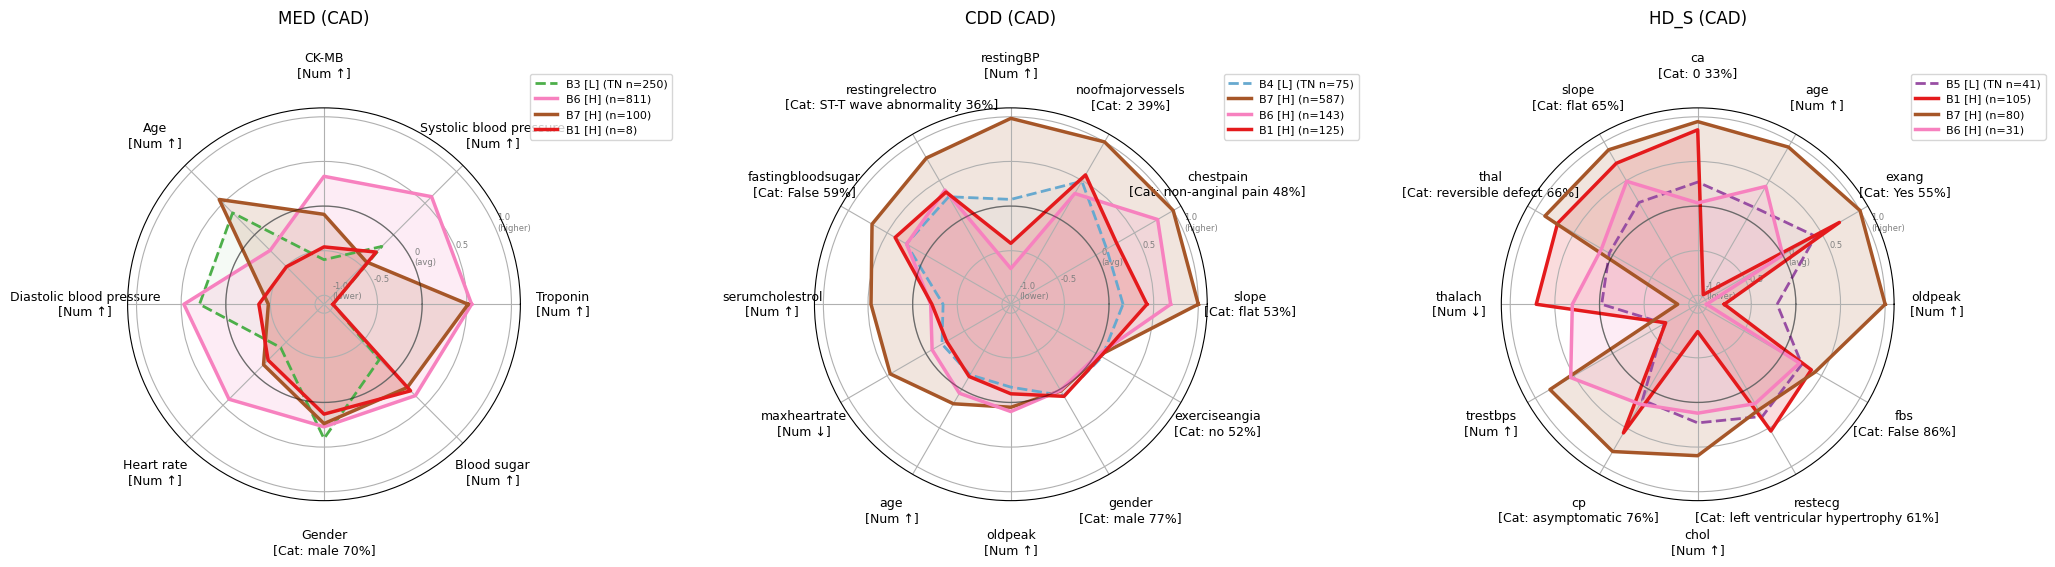

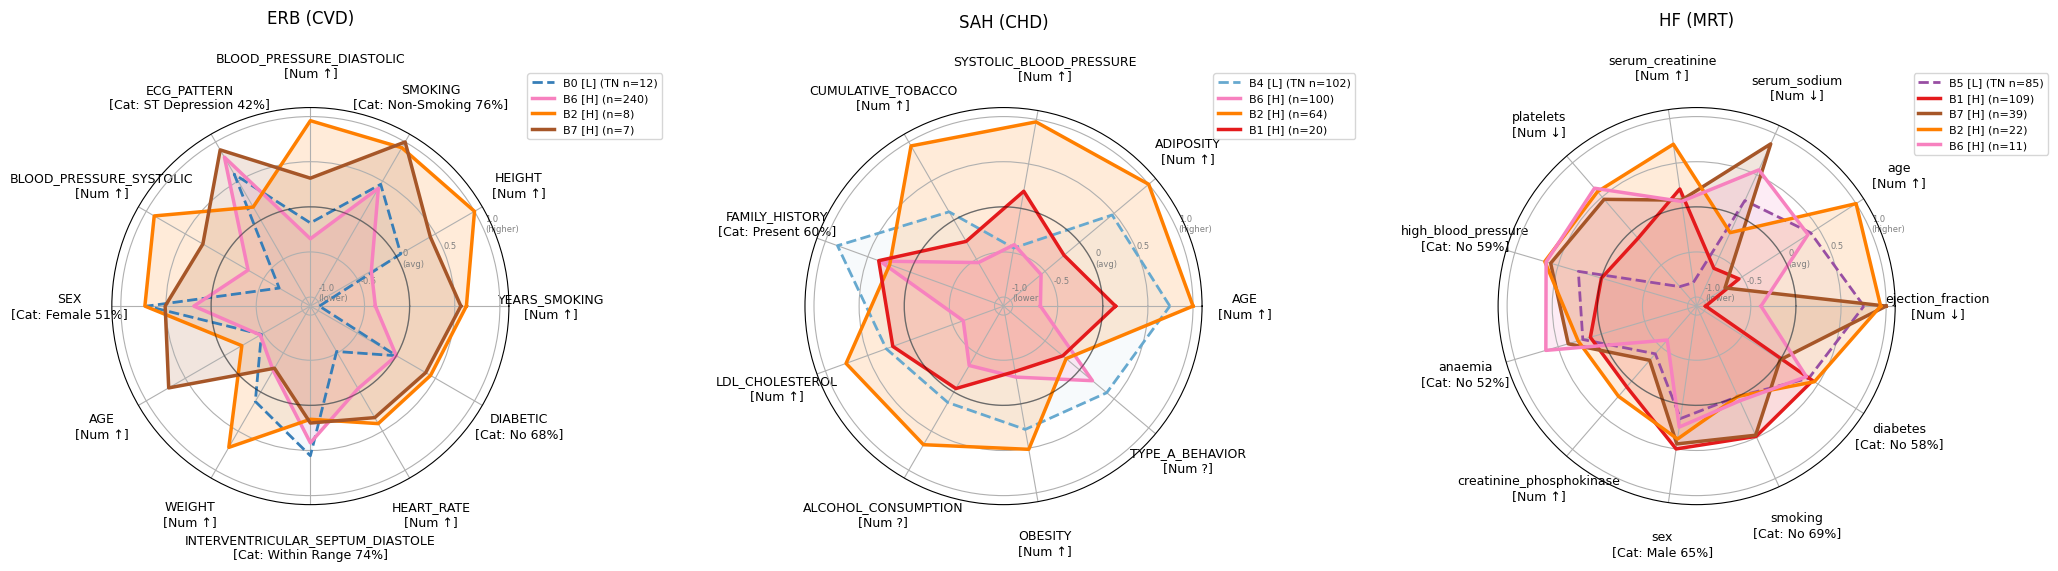

In [27]:
save_radar_pval_v3_combined(all_results, onehot_probs, sources)

In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, chi2_contingency

DATASET_SHORT_NAMES = {
    'Medicaldataset': 'MED (CAD)',
    'Cardiovascular_Disease_Dataset': 'CDD (CAD)',
    'heart': 'HD (CAD)',
    'Heart_disease_statlog': 'HD_S (CAD)',
    'Erbil_Cardiovascular_Health_Dataset': 'ERB (CVD)',
    'cardio_SAheart': 'SAH (CHD)',
    'heart_failure_clinical_records': 'HF (MRT)',
}

# Clinical risk direction: ↑ = higher is risky, ↓ = lower is risky
RISK_DIRECTION = {
    # Blood pressure
    'systolic blood pressure': '↑', 'Systolic blood pressure': '↑',
    'SYSTOLIC_BLOOD_PRESSURE': '↑', 'BLOOD_PRESSURE_SYSTOLIC': '↑',
    'diastolic blood pressure': '↑', 'Diastolic blood pressure': '↑',
    'BLOOD_PRESSURE_DIASTOLIC': '↑',
    'restingBP': '↑', 'trestbps': '↑', 'restingbp': '↑',
    # Cholesterol / lipids
    'serumcholestrol': '↑', 'cholesterol': '↑', 'Cholesterol': '↑',
    'chol': '↑', 'LDL_CHOLESTEROL': '↑',
    # Blood sugar
    'Blood sugar': '↑', 'blood_sugar': '↑',
    # Cardiac biomarkers
    'CK-MB': '↑', 'Troponin': '↑',
    'creatinine_phosphokinase': '↑',
    'serum_creatinine': '↑',
    # Age
    'Age': '↑', 'age': '↑', 'AGE': '↑',
    # Heart rate (resting = higher is risky)
    'Heart rate': '↑', 'HEART_RATE': '↑',
    # Max heart rate (lower is risky)
    'maxheartrate': '↓', 'thalach': '↓', 'maxHR': '↓',
    # Exercise / ST
    'oldpeak': '↑', 'Oldpeak': '↑',
    # Ejection fraction (lower is risky)
    'ejection_fraction': '↓',
    # Serum sodium (lower is risky)
    'serum_sodium': '↓',
    # Platelets (lower is risky in HF)
    'platelets': '↓',
    # Body composition
    'OBESITY': '↑', 'ADIPOSITY': '↑', 'WEIGHT': '↑', 'weight': '↑',
    'HEIGHT': '↑',
    # Smoking / tobacco
    'CUMULATIVE_TOBACCO': '↑', 'YEARS_SMOKING': '↑',
    # Hypertension
    'HYPERTENSION': '↑',
}

EXCLUDE_FEATURES = {'patientid', 'patient_id', 'id', 'ID', 'time'}

BASIS_COLORS = {
    'B0': '#377eb8', 'B1': '#e41a1c', 'B2': '#ff7f00', 'B3': '#4daf4a',
    'B4': '#67a9cf', 'B5': '#984ea3', 'B6': '#f781bf', 'B7': '#a65628',
}

def detect_ftypes_v3(X):
    num_cols, cat_cols = [], []
    for col in X.columns:
        if col.lower() in {f.lower() for f in EXCLUDE_FEATURES}:
            continue
        if X[col].dtype in ['object', 'category'] or X[col].nunique() <= 5:
            cat_cols.append(col)
        else:
            num_cols.append(col)
    return num_cols, cat_cols


def compute_signed_profile_v3(X, argmax, basis_k, num_cols, cat_cols, ys):
    """Compute signed importance: +/-sqrt(-log10(p)/cap) for num and cat."""
    in_group = (argmax == basis_k)
    out_group = ~in_group
    if in_group.sum() < 3 or out_group.sum() < 3:
        return None, None, None, None

    features, raw_scores, signs, ftypes = [], [], [], []
    pos_mask = (ys == 1)

    for col in num_cols:
        vals_in = X.loc[in_group, col].dropna()
        vals_out = X.loc[out_group, col].dropna()
        if len(vals_in) < 2 or len(vals_out) < 2:
            continue
        try:
            _, p = ttest_ind(vals_in, vals_out, equal_var=False)
            if p < 1e-300: p = 1e-300
            score = -np.log10(p)
            sign = 1.0 if vals_in.mean() > vals_out.mean() else -1.0
            features.append(col)
            raw_scores.append(score)
            signs.append(sign)
            ftypes.append('num')
        except:
            continue

    for col in cat_cols:
        try:
            ct = pd.crosstab(in_group, X[col])
            if ct.shape[0] < 2 or ct.shape[1] < 2: continue
            _, p, _, _ = chi2_contingency(ct)
            if p < 1e-300: p = 1e-300
            score = -np.log10(p)
            # Risky category = mode of positive patients
            pos_vals = X.loc[pos_mask, col].dropna()
            if len(pos_vals) > 0:
                risky_cat = pos_vals.mode().iloc[0]
            else:
                risky_cat = X[col].mode().iloc[0]
            in_prop = (X.loc[in_group, col] == risky_cat).mean()
            out_prop = (X.loc[out_group, col] == risky_cat).mean()
            sign = 1.0 if in_prop >= out_prop else -1.0
            features.append(col)
            raw_scores.append(score)
            signs.append(sign)
            ftypes.append('cat')
        except:
            continue

    return features, raw_scores, signs, ftypes


def plot_radar_pval_v3(result, onehot_probs, ax, min_n=5, max_features=12):
    src_name = result['dataset_name']
    X = result['X']
    argmax = result['argmax']
    ys = result['ys']
    M = result['pis'].shape[1]
    short_name = DATASET_SHORT_NAMES.get(src_name, src_name)

    num_cols, cat_cols = detect_ftypes_v3(X)

    high_risk_bases = [k for k in range(M) if onehot_probs[k] > 0.5]
    low_risk_bases = [k for k in range(M) if onehot_probs[k] <= 0.5]

    active_h = []
    for k in high_risk_bases:
        n = (argmax == k).sum()
        if n >= min_n:
            active_h.append((k, int(n)))
    active_h.sort(key=lambda x: -x[1])
    active_h = active_h[:5]

    tn_ref, best_tn_n = None, 0
    for k in low_risk_bases:
        n = (argmax == k).sum()
        if n >= min_n and n > best_tn_n:
            tn_ref, best_tn_n = k, int(n)

    draw_list = []
    if tn_ref is not None:
        draw_list.append((tn_ref, 'tn_ref', best_tn_n))
    for k, n in active_h:
        draw_list.append((k, 'high', n))

    if not draw_list:
        ax.text(0.5, 0.5, f'[{short_name}]\nNo active bases', ha='center', va='center', transform=ax.transAxes)
        return

    # Collect profiles
    all_profiles = {}
    all_signs = {}
    all_feature_sets = set()
    all_ftypes_map = {}

    for k, kind, n in draw_list:
        res = compute_signed_profile_v3(X, argmax, k, num_cols, cat_cols, ys)
        if res[0] is None: continue
        features, raw_scores, signs, ftypes = res
        all_profiles[k] = dict(zip(features, raw_scores))
        all_signs[k] = dict(zip(features, signs))
        all_feature_sets.update(features)
        for f, ft in zip(features, ftypes):
            all_ftypes_map[f] = ft

    if not all_profiles or not all_feature_sets:
        ax.text(0.5, 0.5, f'[{short_name}]\nNo significant features', ha='center', va='center', transform=ax.transAxes)
        return

    # Select top features by max raw score
    feature_max = {f: max(p.get(f, 0) for p in all_profiles.values()) for f in all_feature_sets}
    top_features = sorted(feature_max, key=lambda f: -feature_max[f])[:max_features]

    if len(top_features) < 3:
        ax.text(0.5, 0.5, f'[{short_name}]\nToo few features', ha='center', va='center', transform=ax.transAxes)
        return

    # Build raw score matrix
    raw_matrix = np.zeros((len(draw_list), len(top_features)))
    sign_matrix = np.ones((len(draw_list), len(top_features)))
    valid_bases = []
    for i, (k, kind, n) in enumerate(draw_list):
        if k not in all_profiles: continue
        valid_bases.append(i)
        for j, f in enumerate(top_features):
            raw_matrix[i, j] = all_profiles[k].get(f, 0)
            sign_matrix[i, j] = all_signs[k].get(f, 1.0)

    # Cap + sqrt normalize (unsigned)
    all_vals = raw_matrix[valid_bases].flatten()
    cap_val = np.percentile(all_vals, 95)
    if cap_val < 1.0: cap_val = all_vals.max()
    if cap_val < 1e-9:
        norm_matrix = np.zeros_like(raw_matrix)
    else:
        norm_matrix = np.sqrt(np.clip(raw_matrix, 0, cap_val) / cap_val)

    # Apply sign: positive = outward, negative = inward
    signed_matrix = norm_matrix * sign_matrix

    # Draw radar
    n_features = len(top_features)
    angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
    angles += angles[:1]

    for i, (k, kind, n) in enumerate(draw_list):
        if i not in valid_bases: continue
        color = BASIS_COLORS.get(f'B{k}', '#999999')
        values = signed_matrix[i].tolist() + [signed_matrix[i, 0]]

        if kind == 'tn_ref':
            ls, lw, af = '--', 2.0, 0.05
            label = f'B{k} [L] (TN n={n})'
        else:
            ls, lw, af = '-', 2.5, 0.15
            label = f'B{k} [H] (n={n})'

        ax.plot(angles, values, color=color, linewidth=lw, linestyle=ls, label=label)
        ax.fill(angles, values, color=color, alpha=af)

    # Feature labels: unified format
    labels = []
    pos_mask = (ys == 1)
    for f in top_features:
        ftype = all_ftypes_map.get(f, 'num')
        if ftype == 'num':
            arrow = RISK_DIRECTION.get(f, '?')
            labels.append(f'{f}\n[Num {arrow}]')
        else:
            pos_vals = X.loc[pos_mask, f].dropna()
            if len(pos_vals) > 0:
                mode_val = pos_vals.mode().iloc[0]
                mode_pct = (pos_vals == mode_val).mean() * 100
                labels.append(f'{f}\n[Cat: {mode_val} {mode_pct:.0f}%]')
            else:
                labels.append(f'{f}\n[Cat]')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9, color='black')
    ax.tick_params(axis='x', pad=20)

    # Y-axis: -1 to +1, 0 as clear baseline
    ax.set_ylim(-1.1, 1.1)
    ax.set_yticks([-1.0, -0.5, 0, 0.5, 1.0])
    ax.set_yticklabels(['-1.0\n(lower)', '-0.5', '0\n(avg)', '0.5', '1.0\n(higher)'],
                       fontsize=6, color='gray')

    # Bold zero line
    zero_angles = np.linspace(0, 2 * np.pi, 100)
    ax.plot(zero_angles, [0] * 100, color='black', linewidth=1.0, linestyle='-', alpha=0.4)

    ax.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.4, 1.1))
    ax.set_title(f'{short_name}', fontsize=12, pad=20)


def save_radar_pval_v3_combined(all_results, onehot_probs, sources, save_path=None):
    n_per_row = 3
    n_figs = (len(sources) + n_per_row - 1) // n_per_row
    for fig_idx in range(n_figs):
        start = fig_idx * n_per_row
        end = min(start + n_per_row, len(sources))
        batch = sources[start:end]
        n = len(batch)
        fig, axes = plt.subplots(1, n, figsize=(7 * n, 7), subplot_kw=dict(polar=True))
        if n == 1: axes = [axes]
        for i, src in enumerate(batch):
            if src in all_results:
                plot_radar_pval_v3(all_results[src], onehot_probs, axes[i])
        plt.tight_layout()
        if save_path:
            base, ext = os.path.splitext(save_path)
            fig.savefig(f'{base}_part{fig_idx+1}{ext}', dpi=150, bbox_inches='tight')
            plt.close(fig)
        else:
            plt.show()

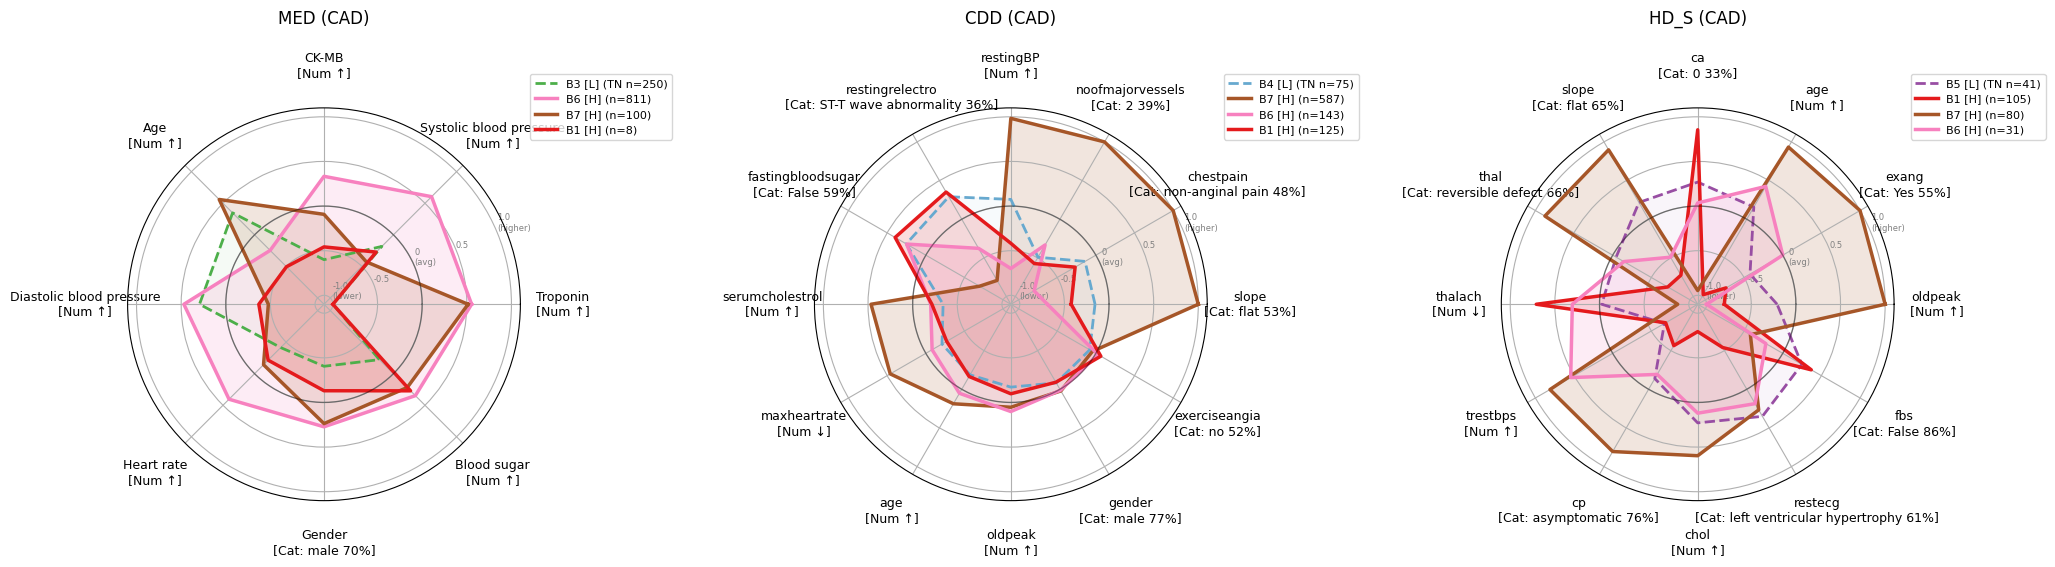

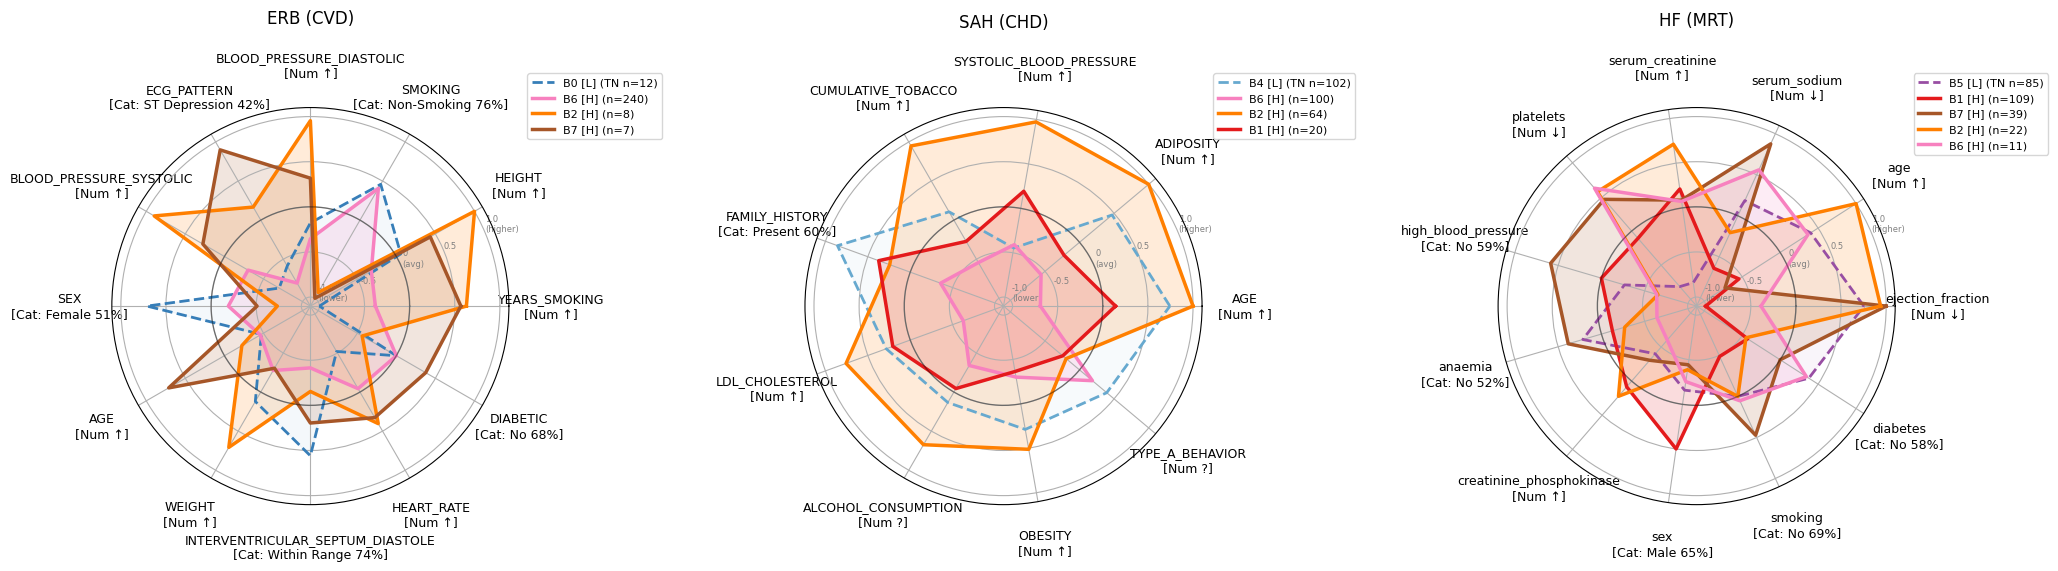

In [29]:
save_radar_pval_v3_combined(all_results, onehot_probs, sources)

In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, chi2_contingency

DATASET_SHORT_NAMES = {
    'Medicaldataset': 'MED (CAD)',
    'Cardiovascular_Disease_Dataset': 'CDD (CAD)',
    'heart': 'HD (CAD)',
    'Heart_disease_statlog': 'HD_S (CAD)',
    'Erbil_Cardiovascular_Health_Dataset': 'ERB (CVD)',
    'cardio_SAheart': 'SAH (CHD)',
    'heart_failure_clinical_records': 'HF (MRT)',
}

# Clinical risk direction: ↑ = higher is risky, ↓ = lower is risky
RISK_DIRECTION = {
    # === Blood pressure (all datasets) ===
    'Systolic blood pressure': '↑', 'SYSTOLIC_BLOOD_PRESSURE': '↑',
    'BLOOD_PRESSURE_SYSTOLIC': '↑', 'restingBP': '↑', 'trestbps': '↑',
    'Diastolic blood pressure': '↑', 'BLOOD_PRESSURE_DIASTOLIC': '↑',
    # === Cholesterol / lipids ===
    'serumcholestrol': '↑', 'cholesterol': '↑', 'Cholesterol': '↑',
    'chol': '↑', 'LDL_CHOLESTEROL': '↑',
    # === Blood sugar ===
    'Blood sugar': '↑',
    # === Cardiac biomarkers ===
    'CK-MB': '↑', 'Troponin': '↑',
    'creatinine_phosphokinase': '↑',
    'serum_creatinine': '↑',
    # === Age ===
    'Age': '↑', 'age': '↑', 'AGE': '↑',
    # === Heart rate (resting: higher is risky) ===
    'Heart rate': '↑', 'HEART_RATE': '↑',
    # === Max heart rate (lower is risky: lower max HR = worse cardiac function) ===
    'maxheartrate': '↓', 'thalach': '↓', 'maxHR': '↓',
    # === Exercise / ST ===
    'oldpeak': '↑', 'Oldpeak': '↑',
    # === Major vessels (more blocked = worse) ===
    'noofmajorvessels': '↑', 'ca': '↑',
    # === Ejection fraction (lower = worse heart function) ===
    'ejection_fraction': '↓',
    # === Serum sodium (lower = worse in HF) ===
    'serum_sodium': '↓',
    # === Platelets (lower = risky in HF) ===
    'platelets': '↓',
    # === Body composition / metabolic ===
    'OBESITY': '↑', 'ADIPOSITY': '↑',
    'WEIGHT': '↑', 'weight': '↑',
    # === Smoking / tobacco ===
    'CUMULATIVE_TOBACCO': '↑', 'YEARS_SMOKING': '↑',
    # === Behavioral / lifestyle ===
    'TYPE_A_BEHAVIOR': '↑',
    'ALCOHOL_CONSUMPTION': '↑',
    # === Follow-up (shorter = more severe) ===
    'time': '↓',
    # === Body height ===
    'HEIGHT': '↑',
    # === Hypertension ===
    'HYPERTENSION': '↑',
}

EXCLUDE_FEATURES = {'patientid', 'patient_id', 'id', 'ID'}

BASIS_COLORS = {
    'B0': '#377eb8', 'B1': '#e41a1c', 'B2': '#ff7f00', 'B3': '#4daf4a',
    'B4': '#67a9cf', 'B5': '#984ea3', 'B6': '#f781bf', 'B7': '#a65628',
}

def detect_ftypes_v3(X):
    num_cols, cat_cols = [], []
    for col in X.columns:
        if col.lower() in {f.lower() for f in EXCLUDE_FEATURES}:
            continue
        if X[col].dtype in ['object', 'category'] or X[col].nunique() <= 5:
            cat_cols.append(col)
        else:
            num_cols.append(col)
    return num_cols, cat_cols


def compute_signed_profile_v3(X, argmax, basis_k, num_cols, cat_cols, ys):
    """Compute signed importance: +/-sqrt(-log10(p)/cap) for num and cat."""
    in_group = (argmax == basis_k)
    out_group = ~in_group
    if in_group.sum() < 3 or out_group.sum() < 3:
        return None, None, None, None

    features, raw_scores, signs, ftypes = [], [], [], []
    pos_mask = (ys == 1)

    for col in num_cols:
        vals_in = X.loc[in_group, col].dropna()
        vals_out = X.loc[out_group, col].dropna()
        if len(vals_in) < 2 or len(vals_out) < 2:
            continue
        try:
            _, p = ttest_ind(vals_in, vals_out, equal_var=False)
            if p < 1e-300: p = 1e-300
            score = -np.log10(p)
            sign = 1.0 if vals_in.mean() > vals_out.mean() else -1.0
            features.append(col)
            raw_scores.append(score)
            signs.append(sign)
            ftypes.append('num')
        except:
            continue

    for col in cat_cols:
        try:
            ct = pd.crosstab(in_group, X[col])
            if ct.shape[0] < 2 or ct.shape[1] < 2: continue
            _, p, _, _ = chi2_contingency(ct)
            if p < 1e-300: p = 1e-300
            score = -np.log10(p)
            # Risky category = mode of positive patients
            pos_vals = X.loc[pos_mask, col].dropna()
            if len(pos_vals) > 0:
                risky_cat = pos_vals.mode().iloc[0]
            else:
                risky_cat = X[col].mode().iloc[0]
            in_prop = (X.loc[in_group, col] == risky_cat).mean()
            out_prop = (X.loc[out_group, col] == risky_cat).mean()
            sign = 1.0 if in_prop >= out_prop else -1.0
            features.append(col)
            raw_scores.append(score)
            signs.append(sign)
            ftypes.append('cat')
        except:
            continue

    return features, raw_scores, signs, ftypes


def plot_radar_pval_v3(result, onehot_probs, ax, min_n=5, max_features=12):
    src_name = result['dataset_name']
    X = result['X']
    argmax = result['argmax']
    ys = result['ys']
    M = result['pis'].shape[1]
    short_name = DATASET_SHORT_NAMES.get(src_name, src_name)

    num_cols, cat_cols = detect_ftypes_v3(X)

    high_risk_bases = [k for k in range(M) if onehot_probs[k] > 0.5]
    low_risk_bases = [k for k in range(M) if onehot_probs[k] <= 0.5]

    active_h = []
    for k in high_risk_bases:
        n = (argmax == k).sum()
        if n >= min_n:
            active_h.append((k, int(n)))
    active_h.sort(key=lambda x: -x[1])
    active_h = active_h[:5]

    tn_ref, best_tn_n = None, 0
    for k in low_risk_bases:
        n = (argmax == k).sum()
        if n >= min_n and n > best_tn_n:
            tn_ref, best_tn_n = k, int(n)

    draw_list = []
    if tn_ref is not None:
        draw_list.append((tn_ref, 'tn_ref', best_tn_n))
    for k, n in active_h:
        draw_list.append((k, 'high', n))

    if not draw_list:
        ax.text(0.5, 0.5, f'[{short_name}]\nNo active bases', ha='center', va='center', transform=ax.transAxes)
        return

    # Collect profiles
    all_profiles = {}
    all_signs = {}
    all_feature_sets = set()
    all_ftypes_map = {}

    for k, kind, n in draw_list:
        res = compute_signed_profile_v3(X, argmax, k, num_cols, cat_cols, ys)
        if res[0] is None: continue
        features, raw_scores, signs, ftypes = res
        all_profiles[k] = dict(zip(features, raw_scores))
        all_signs[k] = dict(zip(features, signs))
        all_feature_sets.update(features)
        for f, ft in zip(features, ftypes):
            all_ftypes_map[f] = ft

    if not all_profiles or not all_feature_sets:
        ax.text(0.5, 0.5, f'[{short_name}]\nNo significant features', ha='center', va='center', transform=ax.transAxes)
        return

    # Select top features by max raw score
    feature_max = {f: max(p.get(f, 0) for p in all_profiles.values()) for f in all_feature_sets}
    top_features = sorted(feature_max, key=lambda f: -feature_max[f])[:max_features]

    if len(top_features) < 3:
        ax.text(0.5, 0.5, f'[{short_name}]\nToo few features', ha='center', va='center', transform=ax.transAxes)
        return

    # Build raw score matrix
    raw_matrix = np.zeros((len(draw_list), len(top_features)))
    sign_matrix = np.ones((len(draw_list), len(top_features)))
    valid_bases = []
    for i, (k, kind, n) in enumerate(draw_list):
        if k not in all_profiles: continue
        valid_bases.append(i)
        for j, f in enumerate(top_features):
            raw_matrix[i, j] = all_profiles[k].get(f, 0)
            sign_matrix[i, j] = all_signs[k].get(f, 1.0)

    # Cap + sqrt normalize (unsigned)
    all_vals = raw_matrix[valid_bases].flatten()
    cap_val = np.percentile(all_vals, 95)
    if cap_val < 1.0: cap_val = all_vals.max()
    if cap_val < 1e-9:
        norm_matrix = np.zeros_like(raw_matrix)
    else:
        norm_matrix = np.sqrt(np.clip(raw_matrix, 0, cap_val) / cap_val)

    # Apply sign: positive = outward, negative = inward
    signed_matrix = norm_matrix * sign_matrix

    # Draw radar
    n_features = len(top_features)
    angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
    angles += angles[:1]

    for i, (k, kind, n) in enumerate(draw_list):
        if i not in valid_bases: continue
        color = BASIS_COLORS.get(f'B{k}', '#999999')
        values = signed_matrix[i].tolist() + [signed_matrix[i, 0]]

        if kind == 'tn_ref':
            ls, lw, af = '--', 2.0, 0.05
            label = f'B{k} [L] (TN n={n})'
        else:
            ls, lw, af = '-', 2.5, 0.15
            label = f'B{k} [H] (n={n})'

        ax.plot(angles, values, color=color, linewidth=lw, linestyle=ls, label=label)
        ax.fill(angles, values, color=color, alpha=af)

    # Feature labels: unified format
    labels = []
    pos_mask = (ys == 1)
    for f in top_features:
        ftype = all_ftypes_map.get(f, 'num')
        if ftype == 'num':
            arrow = RISK_DIRECTION.get(f, '?')
            labels.append(f'{f}\n[Num {arrow}]')
        else:
            pos_vals = X.loc[pos_mask, f].dropna()
            if len(pos_vals) > 0:
                mode_val = pos_vals.mode().iloc[0]
                mode_pct = (pos_vals == mode_val).mean() * 100
                labels.append(f'{f}\n[Cat: {mode_val} {mode_pct:.0f}%]')
            else:
                labels.append(f'{f}\n[Cat]')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9, color='black')
    ax.tick_params(axis='x', pad=20)

    # Y-axis: -1 to +1, 0 as clear baseline
    ax.set_ylim(-1.1, 1.1)
    ax.set_yticks([-1.0, -0.5, 0, 0.5, 1.0])
    ax.set_yticklabels(['-1.0\n(lower)', '-0.5', '0\n(avg)', '0.5', '1.0\n(higher)'],
                       fontsize=6, color='gray')

    # Bold zero line
    zero_angles = np.linspace(0, 2 * np.pi, 100)
    ax.plot(zero_angles, [0] * 100, color='black', linewidth=1.0, linestyle='-', alpha=0.4)

    ax.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.4, 1.1))
    ax.set_title(f'{short_name}', fontsize=12, pad=20)


def save_radar_pval_v3_combined(all_results, onehot_probs, sources, save_path=None):
    n_per_row = 3
    n_figs = (len(sources) + n_per_row - 1) // n_per_row
    for fig_idx in range(n_figs):
        start = fig_idx * n_per_row
        end = min(start + n_per_row, len(sources))
        batch = sources[start:end]
        n = len(batch)
        fig, axes = plt.subplots(1, n, figsize=(7 * n, 7), subplot_kw=dict(polar=True))
        if n == 1: axes = [axes]
        for i, src in enumerate(batch):
            if src in all_results:
                plot_radar_pval_v3(all_results[src], onehot_probs, axes[i])
        plt.tight_layout()
        if save_path:
            base, ext = os.path.splitext(save_path)
            fig.savefig(f'{base}_part{fig_idx+1}{ext}', dpi=150, bbox_inches='tight')
            plt.close(fig)
        else:
            plt.show()

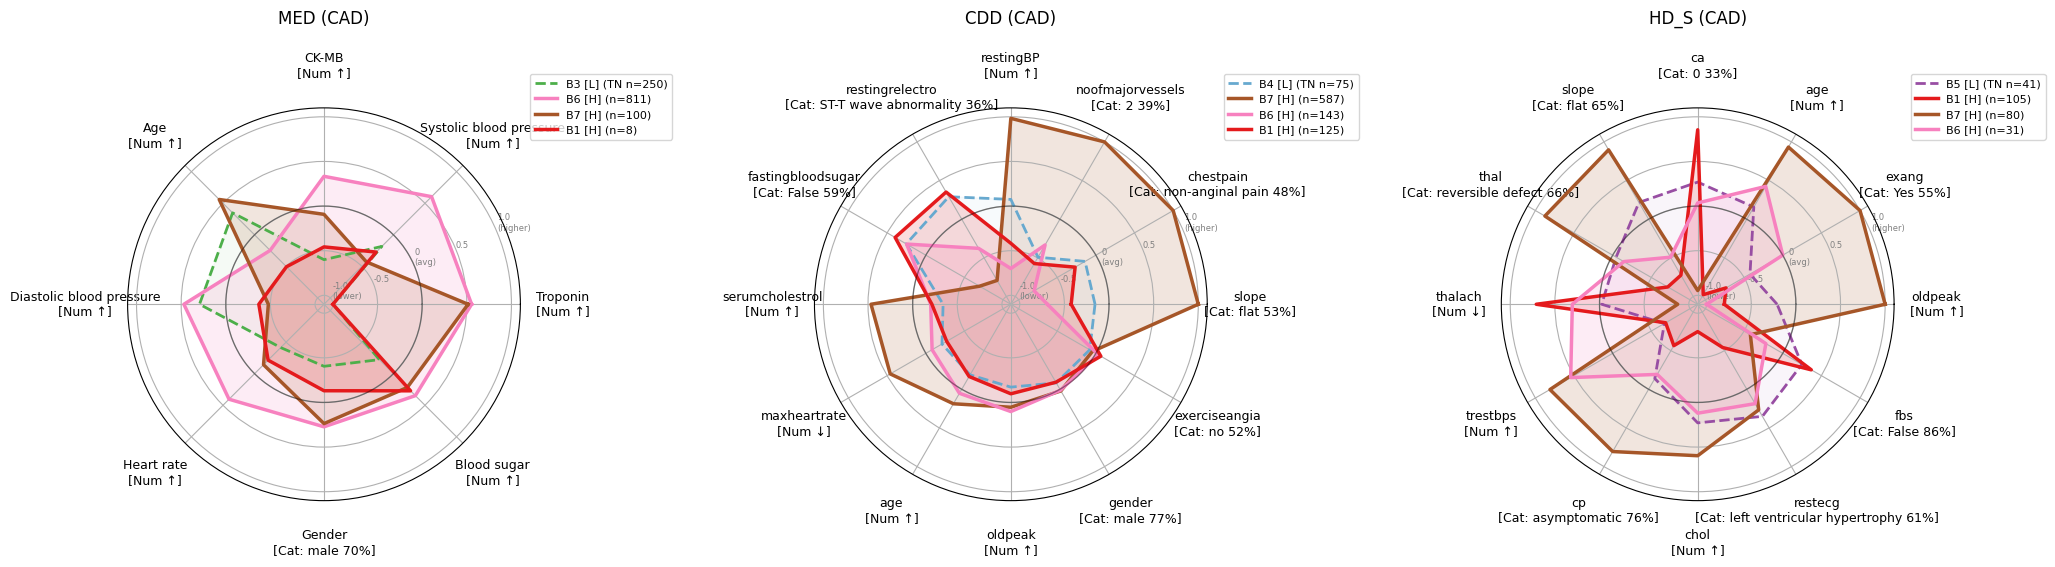

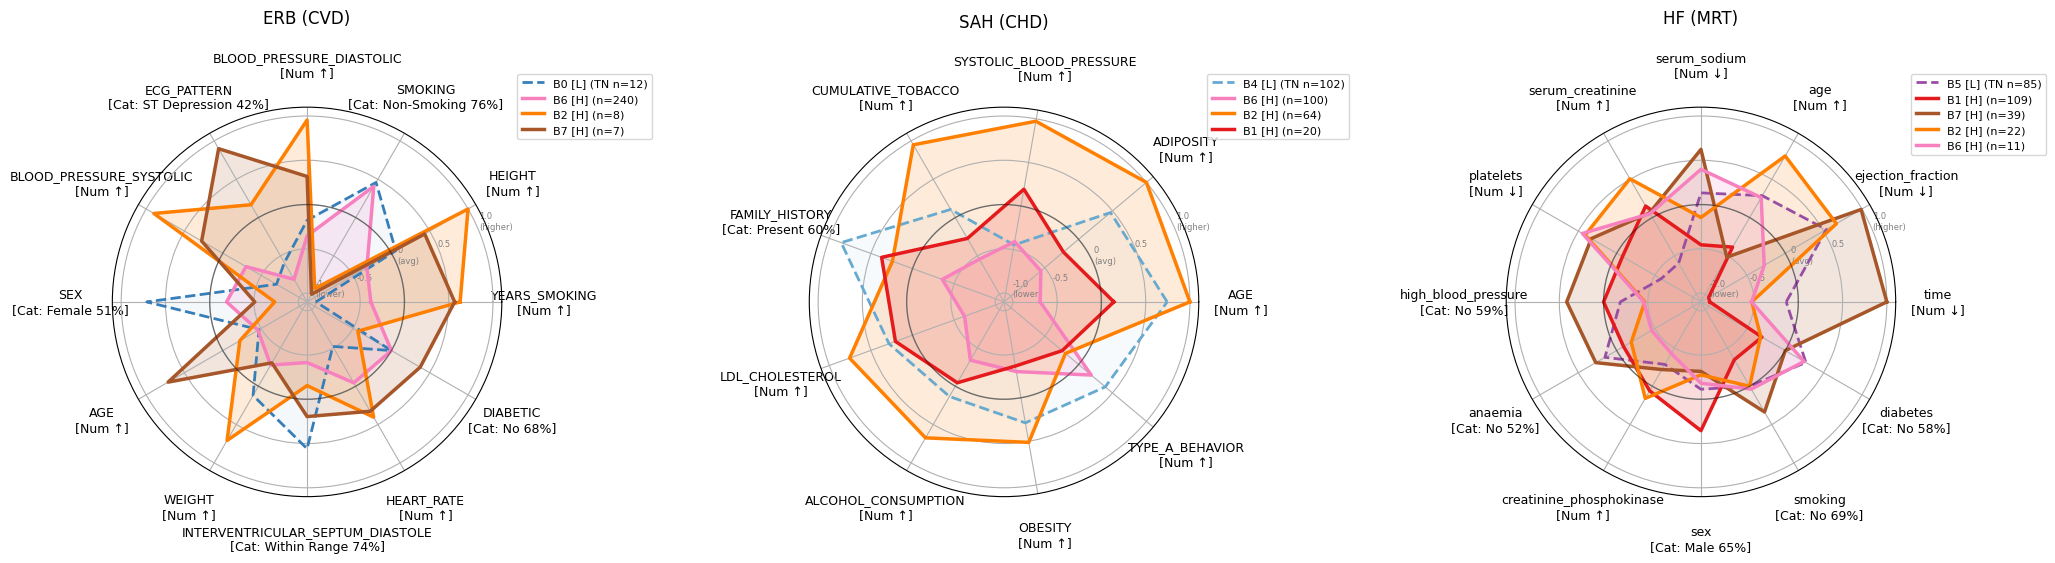

In [31]:
save_radar_pval_v3_combined(all_results, onehot_probs, sources)

In [32]:
# 실제 수치 추출
for src in sources:
    if src not in all_results: continue
    res = all_results[src]
    X, argmax, ys = res['X'], res['argmax'], res['ys']
    M = res['pis'].shape[1]
    num_cols, cat_cols = detect_ftypes_v3(X)
    
    short = DATASET_SHORT_NAMES.get(src, src)
    print(f"\n{'='*60}")
    print(f"  {short}  (src={src})")
    print(f"{'='*60}")
    
    for k in range(M):
        n = (argmax == k).sum()
        if n < 3: continue
        risk = 'H' if onehot_probs[k] > 0.5 else 'L'
        r = compute_signed_profile_v3(X, argmax, k, num_cols, cat_cols, ys)
        if r[0] is None: continue
        features, scores, signs, ftypes = r
        print(f"\n  B{k} [{risk}] (n={n})")
        for f, s, sg, ft in zip(features, scores, signs, ftypes):
            direction = '+' if sg > 0 else '-'
            print(f"    {direction} {f:30s} [{ft}]  raw={s:.2f}")


  MED (CAD)  (src=Medicaldataset)

  B0 [L] (n=67)
    - Age                            [num]  raw=3.65
    - Heart rate                     [num]  raw=3.25
    - Systolic blood pressure        [num]  raw=3.04
    - Diastolic blood pressure       [num]  raw=1.47
    - Blood sugar                    [num]  raw=6.03
    - CK-MB                          [num]  raw=1.35
    - Troponin                       [num]  raw=26.01
    - Gender                         [cat]  raw=0.07

  B1 [H] (n=8)
    - Age                            [num]  raw=3.73
    - Heart rate                     [num]  raw=0.67
    - Systolic blood pressure        [num]  raw=1.09
    - Diastolic blood pressure       [num]  raw=2.00
    + Blood sugar                    [num]  raw=1.08
    - CK-MB                          [num]  raw=3.06
    - Troponin                       [num]  raw=26.85
    - Gender                         [cat]  raw=0.25

  B3 [L] (n=250)
    + Age                            [num]  raw=1.77
    - Heart

In [ ]:
"""
Editable Radar System
1. export_radar_data() → dict 출력 (복사해서 수정 가능)
2. draw_radar_from_data(data) → 수정된 dict로 radar 그리기

Workflow:
  data = export_radar_data(all_results, onehot_probs, sources)
  # data 수치 수정
  draw_radar_from_data(data)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

RISK_DIRECTION = {
    'Systolic blood pressure': '↑', 'SYSTOLIC_BLOOD_PRESSURE': '↑',
    'BLOOD_PRESSURE_SYSTOLIC': '↑', 'restingBP': '↑', 'trestbps': '↑',
    'Diastolic blood pressure': '↑', 'BLOOD_PRESSURE_DIASTOLIC': '↑',
    'RestingBP': '↑',
    'serumcholestrol': '↑', 'cholesterol': '↑', 'Cholesterol': '↑',
    'chol': '↑', 'LDL_CHOLESTEROL': '↑',
    'Blood sugar': '↑',
    'CK-MB': '↑', 'Troponin': '↑',
    'creatinine_phosphokinase': '↑', 'serum_creatinine': '↑',
    'Age': '↑', 'age': '↑', 'AGE': '↑',
    'Heart rate': '↑', 'HEART_RATE': '↑',
    'maxheartrate': '↓', 'thalach': '↓', 'maxHR': '↓', 'MaxHR': '↓',
    'oldpeak': '↑', 'Oldpeak': '↑',
    'noofmajorvessels': '↑', 'ca': '↑',
    'ejection_fraction': '↓', 'serum_sodium': '↓', 'platelets': '↓',
    'OBESITY': '↑', 'ADIPOSITY': '↑', 'WEIGHT': '↑', 'weight': '↑', 'HEIGHT': '↑',
    'CUMULATIVE_TOBACCO': '↑', 'YEARS_SMOKING': '↑',
    'TYPE_A_BEHAVIOR': '↑', 'ALCOHOL_CONSUMPTION': '↑',
    'time': '↓', 'HYPERTENSION': '↑', 'RestingBP': '↑',
}

DATASET_SHORT_NAMES = {
    'Medicaldataset': 'MED (CAD)',
    'Cardiovascular_Disease_Dataset': 'CDD (CAD)',
    'heart': 'HD (CAD)',
    'Heart_disease_statlog': 'HD (CAD)',
    'Erbil_Cardiovascular_Health_Dataset': 'ERB (CVD)',
    'cardio_SAheart': 'SAH (CHD)',
    'heart_failure_clinical_records': 'HF (MRT)',
}

HDS_TO_HD = {
    'age': 'Age', 'sex': 'Sex', 'cp': 'ChestPainType',
    'trestbps': 'RestingBP', 'chol': 'Cholesterol', 'fbs': 'FastingBS',
    'restecg': 'RestingECG', 'thalach': 'MaxHR', 'exang': 'ExerciseAngina',
    'oldpeak': 'Oldpeak', 'slope': 'ST_Slope',
}

EXCLUDE_FEATURES = {'patientid', 'patient_id', 'id', 'ID'}

BASIS_COLORS = {
    'B0': '#377eb8', 'B1': '#e41a1c', 'B2': '#ff7f00', 'B3': '#4daf4a',
    'B4': '#67a9cf', 'B5': '#984ea3', 'B6': '#f781bf', 'B7': '#a65628',
}


def detect_ftypes(X):
    num_cols, cat_cols = [], []
    for col in X.columns:
        if col.lower() in {f.lower() for f in EXCLUDE_FEATURES}:
            continue
        if X[col].dtype in ['object', 'category'] or X[col].nunique() <= 5:
            cat_cols.append(col)
        else:
            num_cols.append(col)
    return num_cols, cat_cols


def export_radar_data(all_results, onehot_probs, sources, min_n=5, max_features=12):
    """
    실제 checkpoint 수치를 편집 가능한 dict로 export.
    HD_S → HD 변수명 자동 변환.
    
    Returns: dict 구조
    {
        'MED (CAD)': {
            'features': ['CK-MB', 'Systolic blood pressure', ...],
            'ftypes':   ['num',   'num', ...],
            'bases': {
                'B3 [L] (TN n=250)': [(sign, raw), (sign, raw), ...],
                'B6 [H] (n=811)':    [(sign, raw), ...],
            }
        },
        ...
    }
    """
    from scipy.stats import ttest_ind, chi2_contingency

    data = {}
    for src in sources:
        if src not in all_results:
            continue
        res = all_results[src]
        X = res['X'].copy()
        argmax = res['argmax']
        ys = res['ys']
        M = res['pis'].shape[1]
        short = DATASET_SHORT_NAMES.get(src, src)

        # HD_S → HD 변환
        if src == 'Heart_disease_statlog':
            drop_cols = [c for c in X.columns if c not in HDS_TO_HD]
            X = X.drop(columns=drop_cols, errors='ignore')
            X = X.rename(columns=HDS_TO_HD)

        num_cols, cat_cols = detect_ftypes(X)
        pos_mask = (ys == 1)

        high_risk = [k for k in range(M) if onehot_probs[k] > 0.5]
        low_risk = [k for k in range(M) if onehot_probs[k] <= 0.5]

        active_h = [(k, int((argmax == k).sum())) for k in high_risk if (argmax == k).sum() >= min_n]
        active_h.sort(key=lambda x: -x[1])
        active_h = active_h[:5]

        tn_ref, best_tn_n = None, 0
        for k in low_risk:
            n = (argmax == k).sum()
            if n >= min_n and n > best_tn_n:
                tn_ref, best_tn_n = k, int(n)

        draw_list = []
        if tn_ref is not None:
            draw_list.append((tn_ref, 'L', best_tn_n))
        for k, n in active_h:
            draw_list.append((k, 'H', n))

        if not draw_list:
            continue

        # Compute profiles
        all_profiles = {}
        all_signs = {}
        all_feature_sets = set()
        all_ftypes_map = {}

        for k, risk, n in draw_list:
            in_group = (argmax == k)
            out_group = ~in_group
            if in_group.sum() < 3:
                continue

            features, raw_scores, signs, ftypes = [], [], [], []
            for col in num_cols:
                vals_in = X.loc[in_group, col].dropna()
                vals_out = X.loc[out_group, col].dropna()
                if len(vals_in) < 2 or len(vals_out) < 2:
                    continue
                try:
                    _, p = ttest_ind(vals_in, vals_out, equal_var=False)
                    if p < 1e-300: p = 1e-300
                    score = -np.log10(p)
                    sign = 1.0 if vals_in.mean() > vals_out.mean() else -1.0
                    features.append(col); raw_scores.append(round(score, 2))
                    signs.append(sign); ftypes.append('num')
                except:
                    continue

            for col in cat_cols:
                try:
                    ct = pd.crosstab(in_group, X[col])
                    if ct.shape[0] < 2 or ct.shape[1] < 2:
                        continue
                    _, p, _, _ = chi2_contingency(ct)
                    if p < 1e-300: p = 1e-300
                    score = -np.log10(p)
                    pos_vals = X.loc[pos_mask, col].dropna()
                    risky_cat = pos_vals.mode().iloc[0] if len(pos_vals) > 0 else X[col].mode().iloc[0]
                    in_prop = (X.loc[in_group, col] == risky_cat).mean()
                    out_prop = (X.loc[out_group, col] == risky_cat).mean()
                    sign = 1.0 if in_prop >= out_prop else -1.0
                    features.append(col); raw_scores.append(round(score, 2))
                    signs.append(sign); ftypes.append('cat')
                except:
                    continue

            if risk == 'L':
                bname = f'B{k} [L] (TN n={n})'
            else:
                bname = f'B{k} [H] (n={n})'

            all_profiles[bname] = dict(zip(features, raw_scores))
            all_signs[bname] = dict(zip(features, signs))
            all_feature_sets.update(features)
            for f, ft in zip(features, ftypes):
                all_ftypes_map[f] = ft

        if not all_profiles:
            continue

        # Top features
        feature_max = {f: max(p.get(f, 0) for p in all_profiles.values()) for f in all_feature_sets}
        top_features = sorted(feature_max, key=lambda f: -feature_max[f])[:max_features]

        # Build cat info
        cat_info = {}
        for f in top_features:
            if all_ftypes_map.get(f) == 'cat':
                pos_vals = X.loc[pos_mask, f].dropna()
                if len(pos_vals) > 0:
                    mode_val = pos_vals.mode().iloc[0]
                    mode_pct = (pos_vals == mode_val).mean() * 100
                    cat_info[f] = f'{mode_val} {mode_pct:.0f}%'

        # Build output
        bases_out = {}
        for bname in all_profiles:
            vals = []
            for f in top_features:
                raw = all_profiles[bname].get(f, 0.0)
                sign = all_signs[bname].get(f, 1.0)
                vals.append((sign, raw))
            bases_out[bname] = vals

        ftypes_list = [all_ftypes_map.get(f, 'num') for f in top_features]

        data[short] = {
            'features': top_features,
            'ftypes': ftypes_list,
            'cat_info': cat_info,
            'bases': bases_out,
        }

    return data


def print_radar_data(data):
    """편집용 출력: 복사해서 수치 수정 가능"""
    for ds_name, ds in data.items():
        print(f"\n{'='*60}")
        print(f"  {ds_name}")
        print(f"{'='*60}")
        print(f"  Features: {ds['features']}")
        print(f"  Types:    {ds['ftypes']}")
        for bname, vals in ds['bases'].items():
            print(f"\n  '{bname}': [")
            for (sign, raw), feat in zip(vals, ds['features']):
                d = '+' if sign > 0 else '-'
                print(f"    ({sign:+.0f}, {raw:6.2f}),  # {feat}")
            print(f"  ],")


def draw_radar_from_data(data, n_per_row=3):
    """
    data: export_radar_data()에서 나온 dict (수정 가능)
    """
    ds_list = list(data.items())
    n_figs = (len(ds_list) + n_per_row - 1) // n_per_row

    for fig_idx in range(n_figs):
        start = fig_idx * n_per_row
        end = min(start + n_per_row, len(ds_list))
        batch = ds_list[start:end]
        n = len(batch)

        fig, axes = plt.subplots(1, n, figsize=(7 * n, 7), subplot_kw=dict(polar=True))
        if n == 1: axes = [axes]

        for i, (ds_name, ds) in enumerate(batch):
            ax = axes[i]
            features = ds['features']
            ftypes = ds['ftypes']
            cat_info = ds.get('cat_info', {})
            bases = ds['bases']

            n_feat = len(features)
            angles = np.linspace(0, 2 * np.pi, n_feat, endpoint=False).tolist()
            angles += angles[:1]

            # Compute cap from all raw values in this dataset
            all_raws = []
            for vals in bases.values():
                all_raws.extend([abs(r) for s, r in vals])
            cap = np.percentile(all_raws, 95)
            if cap < 1.0: cap = max(all_raws) if all_raws else 1.0

            for bname, vals in bases.items():
                # Parse basis info from name
                bnum = bname.split(' ')[0]  # e.g., 'B3'
                is_tn = '[L]' in bname
                color = BASIS_COLORS.get(bnum, '#999999')

                # Normalize
                normed = []
                for sign, raw in vals:
                    v = np.sqrt(np.clip(abs(raw), 0, cap) / cap) * sign
                    normed.append(v)
                normed_closed = normed + [normed[0]]

                if is_tn:
                    ls, lw, af = '--', 2.0, 0.05
                else:
                    ls, lw, af = '-', 2.5, 0.12

                ax.plot(angles, normed_closed, color=color, linewidth=lw, linestyle=ls, label=bname)
                ax.fill(angles, normed_closed, color=color, alpha=af)

            # Feature labels
            labels = []
            for f, ft in zip(features, ftypes):
                if ft == 'num':
                    arrow = RISK_DIRECTION.get(f, '?')
                    labels.append(f'{f}\n[Num {arrow}]')
                else:
                    info = cat_info.get(f, '')
                    if info:
                        labels.append(f'{f}\n[Cat: {info}]')
                    else:
                        labels.append(f'{f}\n[Cat]')

            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(labels, fontsize=9, color='black')
            ax.tick_params(axis='x', pad=20)
            ax.set_ylim(-1.1, 1.1)
            ax.set_yticks([-1.0, -0.5, 0, 0.5, 1.0])
            ax.set_yticklabels(['-1.0\n(lower)', '-0.5', '0\n(avg)', '0.5', '1.0\n(higher)'],
                               fontsize=6, color='gray')
            z = np.linspace(0, 2 * np.pi, 100)
            ax.plot(z, [0]*100, color='black', linewidth=1.0, alpha=0.4)
            ax.legend(fontsize=7, loc='upper right', bbox_to_anchor=(1.42, 1.1))
            ax.set_title(ds_name, fontsize=12, pad=18)

        plt.tight_layout()
        plt.show()

In [ ]:
"""
전체 6개 데이터셋의 실제 raw 수치.
(sign, raw) 형태. sign: +1=바깥(높다), -1=안쪽(낮다). raw: -log10(p).
수치 수정 후 draw_radar_from_data(RADAR_DATA)로 그리기.
"""

RADAR_DATA = {

# ============================================================
'MED (CAD)': {
    'features': ['Troponin', 'Systolic blood pressure', 'CK-MB', 'Age',
                  'Diastolic blood pressure', 'Heart rate', 'Gender', 'Blood sugar'],
    'ftypes':   ['num', 'num', 'num', 'num', 'num', 'num', 'cat', 'num'],
    'cat_info': {'Gender': 'male 70%'},
    'bases': {
        'B3 [L] (TN n=250)': [
            (-1, 25.93),  # Troponin
            (-1,  0.49),  # Systolic blood pressure
            (-1,  5.27),  # CK-MB
            (+1,  1.77),  # Age
            (+1,  1.27),  # Diastolic blood pressure
            (-1,  2.50),  # Heart rate
            (-1,  2.39),  # Gender
            (-1,  0.72),  # Blood sugar
        ],
        'B6 [H] (n=811)': [
            (+1,  4.48),  # Troponin
            (+1,  5.34),  # Systolic blood pressure
            (+1,  1.62),  # CK-MB
            (-1,  0.89),  # Age
            (+1,  3.22),  # Diastolic blood pressure
            (+1,  2.39),  # Heart rate
            (-1,  1.09),  # Gender
            (+1,  1.17),  # Blood sugar
        ],
        'B7 [H] (n=100)': [
            (+1,  3.86),  # Troponin
            (-1,  2.68),  # Systolic blood pressure
            (-1,  0.13),  # CK-MB
            (+1,  4.58),  # Age
            (-1,  3.32),  # Diastolic blood pressure
            (-1,  0.30),  # Heart rate
            (+1,  0.82),  # Gender
            (+1,  0.70),  # Blood sugar
        ],
        'B1 [H] (n=8)': [
            (-1, 26.85),  # Troponin
            (-1,  1.09),  # Systolic blood pressure
            (-1,  3.06),  # CK-MB
            (-1,  3.73),  # Age
            (-1,  2.00),  # Diastolic blood pressure
            (-1,  0.67),  # Heart rate
            (-1,  0.25),  # Gender
            (+1,  1.08),  # Blood sugar
        ],
    },
},

# ============================================================
'CDD (CAD)': {
    'features': ['slope', 'chestpain', 'noofmajorvessels', 'restingBP',
                  'restingrelectro', 'fastingbloodsugar', 'serumcholestrol',
                  'maxheartrate', 'age', 'oldpeak', 'gender', 'exerciseangia'],
    'ftypes':   ['cat', 'cat', 'cat', 'num', 'cat', 'cat', 'num', 'num', 'num', 'num', 'cat', 'cat'],
    'cat_info': {'slope': 'flat 53%', 'chestpain': 'non-anginal pain 48%',
                 'noofmajorvessels': '2 39%', 'restingrelectro': 'ST-T wave abnormality 36%',
                 'fastingbloodsugar': 'False 59%', 'gender': 'male 77%',
                 'exerciseangia': 'no 52%'},
    'bases': {
        'B4 [L] (TN n=75)': [
            (-1,  1.35),  # slope
            (-1,  1.07),  # chestpain
            (-1, 13.22),  # noofmajorvessels
            (+1,  0.30),  # restingBP
            (+1,  4.63),  # restingrelectro
            (+1,  12.50),  # fastingbloodsugar
            (-1,  6.36),  # serumcholestrol
            (+1,  15.39),  # maxheartrate
            (-1,  1.91),  # age
            (-1,  1.61),  # oldpeak
            (-1,  0.38),  # gender
            (-1,  0.35),  # exerciseangia
        ],
        'B7 [H] (n=587)': [
            (+1, 70.30),  # slope
            (+1, 59.68),  # chestpain
            (+1, 55.71),  # noofmajorvessels
            (+1, 32.83),  # restingBP
            (-1, 34.28),  # restingrelectro
            (-1, 26.45),  # fastingbloodsugar
            (+1, 11.90),  # serumcholestrol
            (+1, 8.58),  # maxheartrate
            (+1,  1.92),  # age
            (+1,  7.16),  # oldpeak
            (+1,  0.02),  # gender
            (-1,  0.11),  # exerciseangia
        ],
        'B6 [H] (n=143)': [
            (-1, 26.08),  # slope
            (-1, 34.89),  # chestpain
            (-1,  6.06),  # noofmajorvessels
            (+1, 26.78),  # restingBP
            (-1,  7.77),  # restingrelectro
            (+1,  3.38),  # fastingbloodsugar
            (-1,  2.23),  # serumcholestrol
            (-1,  0.36),  # maxheartrate
            (+1,  0.15),  # age
            (+1,  0.57),  # oldpeak
            (+1,  0.01),  # gender
            (+1,  0.05),  # exerciseangia
        ],
        'B1 [H] (n=125)': [
            (-1,  9.85),  # slope
            (-1,  3.95),  # chestpain
            (-1, 17.99),  # noofmajorvessels
            (-1,  9.51),  # restingBP
            (+1,  6.75),  # restingrelectro
            (+1,  8.62),  # fastingbloodsugar
            (-1,  2.54),  # serumcholestrol
            (-1,  3.98),  # maxheartrate
            (-1,  1.49),  # age
            (-1,  0.51),  # oldpeak
            (-1,  0.45),  # gender
            (+1,  0.22),  # exerciseangia
        ],
    },
},

# ============================================================
'HD (CAD)': {
    'features': ['Oldpeak', 'ExerciseAngina', 'Age', 'ST_Slope',
                  'MaxHR', 'RestingBP', 'ChestPainType', 'Cholesterol',
                  'RestingECG', 'FastingBS', 'Sex'],
    'ftypes':   ['num', 'cat', 'num', 'cat', 'num', 'num', 'cat', 'num', 'cat', 'cat', 'cat'],
    'cat_info': {'ExerciseAngina': 'Y 55%', 'ST_Slope': 'Flat 65%',
                 'ChestPainType': 'asymptomatic 76%', 'RestingECG': 'left ventricular hypertrophy 61%',
                 'FastingBS': 'False 86%', 'Sex': 'M 83%'},
    'bases': {
        'B5 [L] (TN n=41)': [
            (-1,  0.48),  # Oldpeak
            (-1,  1.94),  # ExerciseAngina
            (-1,  0.27),  # Age
            (+1,  0.51),  # ST_Slope
            (+1,  15.01),  # MaxHR
            (-1,  4.84),  # RestingBP
            (-1,  0.21),  # ChestPainType
            (+1,  0.57),  # Cholesterol
            (+1,  1.33),  # RestingECG
            (+1,  0.66),  # FastingBS
            (+1,  0.00),  # Sex
        ],
        'B7 [H] (n=80)': [
            (+1, 14.03),  # Oldpeak
            (+1, 11.11),  # ExerciseAngina
            (+1,  9.43),  # Age
            (+1,  8.72),  # ST_Slope
            (-1,  8.31),  # MaxHR
            (+1,  7.13),  # RestingBP
            (+1,  7.02),  # ChestPainType
            (+1,  3.86),  # Cholesterol
            (+1,  0.77),  # RestingECG
            (-1,  1.90),  # FastingBS
            (+1,  0.15),  # Sex
        ],
        'B6 [H] (n=31)': [
            (-1, 15.14),  # Oldpeak
            (-1,  0.00),  # ExerciseAngina
            (+1,  1.95),  # Age
            (-1,  2.61),  # ST_Slope
            (+1,  1.00),  # MaxHR
            (+1,  3.19),  # RestingBP
            (-1,  0.40),  # ChestPainType
            (+1,  0.16),  # Cholesterol
            (+1,  0.37),  # RestingECG
            (-1,  0.52),  # FastingBS
            (+1,  0.07),  # Sex
        ],
        'B1 [H] (n=105)': [
            (-1,  6.97),  # Oldpeak
            (-1,  5.82),  # ExerciseAngina
            (-1, 10.32),  # Age
            (-1,  5.67),  # ST_Slope
            (+1,  5.44),  # MaxHR
            (-1,  5.09),  # RestingBP
            (-1,  3.45),  # ChestPainType
            (-1,  6.82),  # Cholesterol
            (-1,  3.16),  # RestingECG
            (+1,  1.48),  # FastingBS
            (-1,  0.67),  # Sex
        ],
    },
},

# ============================================================
'ERB (CVD)': {
    'features': ['YEARS_SMOKING', 'HEIGHT', 'SMOKING', 'BLOOD_PRESSURE_DIASTOLIC',
                  'ECG_PATTERN', 'BLOOD_PRESSURE_SYSTOLIC', 'SEX', 'AGE',
                  'WEIGHT', 'INTERVENTRICULAR_SEPTUM_DIASTOLE', 'HEART_RATE', 'DIABETIC'],
    'ftypes':   ['num', 'num', 'cat', 'num', 'cat', 'num', 'cat', 'num', 'num', 'cat', 'num', 'cat'],
    'cat_info': {'SMOKING': 'Non-Smoking 76%', 'ECG_PATTERN': 'ST Depression 42%',
                 'SEX': 'Female 51%', 'INTERVENTRICULAR_SEPTUM_DIASTOLE': 'Within Range 74%',
                 'DIABETIC': 'No 68%'},
    'bases': {
        'B0 [L] (TN n=12)': [
            (-1, 11.70),  # YEARS_SMOKING
            (+1,  0.01),  # HEIGHT
            (+1,  0.80),  # SMOKING
            (-1,  0.12),  # BLOOD_PRESSURE_DIASTOLIC
            (-1,  1.32),  # ECG_PATTERN
            (-1,  1.88),  # BLOOD_PRESSURE_SYSTOLIC
            (+1,  1.93),  # SEX
            (-1,  0.85),  # AGE
            (+1,  0.06),  # WEIGHT
            (+1,  1.19),  # INTERVENTRICULAR_SEPTUM_DIASTOLE
            (+1,  8.03),  # HEART_RATE
            (-1,  0.00),  # DIABETIC
        ],
        'B6 [H] (n=240)': [
            (-1,  0.55),  # YEARS_SMOKING
            (-1,  0.39),  # HEIGHT
            (+1,  0.63),  # SMOKING
            (+1,  3.48),  # BLOOD_PRESSURE_DIASTOLIC
            (-1,  2.48),  # ECG_PATTERN
            (+1,  3.08),  # BLOOD_PRESSURE_SYSTOLIC
            (-1,  0.14),  # SEX
            (-1,  0.81),  # AGE
            (-1,  0.29),  # WEIGHT
            (-1,  0.66),  # INTERVENTRICULAR_SEPTUM_DIASTOLE
            (-1,  0.01),  # HEART_RATE
            (-1,  0.00),  # DIABETIC
        ],
        'B2 [H] (n=8)': [
            (+1,  1.51),  # YEARS_SMOKING
            (+1,  1.69),  # HEIGHT
            (-1,  3.28),  # SMOKING
            (+1,  0.48),  # BLOOD_PRESSURE_DIASTOLIC
            (+1,  0.11),  # ECG_PATTERN
            (+1,  0.58),  # BLOOD_PRESSURE_SYSTOLIC
            (-1,  2.06),  # SEX
            (-1,  0.19),  # AGE
            (+1,  1.91),  # WEIGHT
            (-1,  0.09),  # INTERVENTRICULAR_SEPTUM_DIASTOLE
            (+1,  0.62),  # HEART_RATE
            (-1,  0.73),  # DIABETIC
        ],
        'B7 [H] (n=7)': [
            (+1,  1.23),  # YEARS_SMOKING
            (+1,  0.72),  # HEIGHT
            (-1,  4.00),  # SMOKING
            (+1,  0.38),  # BLOOD_PRESSURE_DIASTOLIC
            (+1,  3.09),  # ECG_PATTERN
            (+1,  0.29),  # BLOOD_PRESSURE_SYSTOLIC
            (-1,  0.99),  # SEX
            (+1,  1.94),  # AGE
            (-1,  0.36),  # WEIGHT
            (+1,  0.15),  # INTERVENTRICULAR_SEPTUM_DIASTOLE
            (+1,  0.41),  # HEART_RATE
            (+1,  0.54),  # DIABETIC
        ],
    },
},

# ============================================================
'SAH (CHD)': {
    'features': ['AGE', 'ADIPOSITY', 'SYSTOLIC_BLOOD_PRESSURE', 'CUMULATIVE_TOBACCO',
                  'FAMILY_HISTORY', 'LDL_CHOLESTEROL', 'ALCOHOL_CONSUMPTION',
                  'OBESITY', 'TYPE_A_BEHAVIOR'],
    'ftypes':   ['num', 'num', 'num', 'num', 'cat', 'num', 'num', 'num', 'num'],
    'cat_info': {'FAMILY_HISTORY': 'Present 60%'},
    'bases': {
        'B4 [L] (TN n=102)': [
            (+1,  5.14),  # AGE
            (+1,  2.06),  # ADIPOSITY
            (-1,  1.85),  # SYSTOLIC_BLOOD_PRESSURE
            (+1,  0.10),  # CUMULATIVE_TOBACCO
            (+1,  6.84),  # FAMILY_HISTORY
            (+1,  0.74),  # LDL_CHOLESTEROL
            (+1,  0.17),  # ALCOHOL_CONSUMPTION
            (+1,  0.77),  # OBESITY
            (-1,  1.44),  # TYPE_A_BEHAVIOR
        ],
        'B6 [H] (n=100)': [
            (-1,  4.44),  # AGE
            (-1,  2.88),  # ADIPOSITY
            (+1,  7.55),  # SYSTOLIC_BLOOD_PRESSURE
            (-1,  2.74),  # CUMULATIVE_TOBACCO
            (-1,  1.19),  # FAMILY_HISTORY
            (-1,  3.64),  # LDL_CHOLESTEROL
            (-1,  1.08),  # ALCOHOL_CONSUMPTION
            (-1,  0.84),  # OBESITY
            (+1,  0.32),  # TYPE_A_BEHAVIOR
        ],
        'B2 [H] (n=64)': [
            (+1, 24.01),  # AGE
            (+1, 10.81),  # ADIPOSITY
            (+1,  3.80),  # SYSTOLIC_BLOOD_PRESSURE
            (+1,  8.38),  # CUMULATIVE_TOBACCO
            (+1,  0.54),  # FAMILY_HISTORY
            (+1,  5.32),  # LDL_CHOLESTEROL
            (+1,  4.22),  # ALCOHOL_CONSUMPTION
            (+1,  2.43),  # OBESITY
            (-1,  0.35),  # TYPE_A_BEHAVIOR
        ],
        'B1 [H] (n=20)': [
            (+1,  0.18),  # AGE
            (-1,  0.47),  # ADIPOSITY
            (+1,  0.34),  # SYSTOLIC_BLOOD_PRESSURE
            (-1,  0.69),  # CUMULATIVE_TOBACCO
            (+1,  1.28),  # FAMILY_HISTORY
            (+1,  0.39),  # LDL_CHOLESTEROL
            (-1,  0.02),  # ALCOHOL_CONSUMPTION
            (-1,  1.23),  # OBESITY
            (+1,  3.55),  # TYPE_A_BEHAVIOR
        ],
    },
},

# ============================================================
'HF (MRT)': {
    'features': ['time', 'ejection_fraction', 'age', 'serum_sodium',
                  'serum_creatinine', 'platelets', 'high_blood_pressure',
                  'anaemia', 'creatinine_phosphokinase', 'sex', 'smoking', 'diabetes'],
    'ftypes':   ['num', 'num', 'num', 'num', 'num', 'num', 'cat', 'cat', 'num', 'cat', 'cat', 'cat'],
    'cat_info': {'high_blood_pressure': 'No 59%', 'anaemia': 'No 57%',
                 'sex': 'Male 65%', 'smoking': 'No 69%', 'diabetes': 'No 58%'},
    'bases': {
        'B5 [L] (TN n=85)': [
            (-1,  0.09),  # time
            (+1,  1.46),  # ejection_fraction
            (+1,  0.41),  # age
            (+1,  0.09),  # serum_sodium
            (-1,  1.80),  # serum_creatinine
            (-1,  1.70),  # platelets
            (-1,  0.18),  # high_blood_pressure
            (+1,  0.12),  # anaemia
            (-1,  0.41),  # creatinine_phosphokinase
            (-1,  0.06),  # sex
            (+1,  0.00),  # smoking
            (+1,  0.37),  # diabetes
        ],
        'B1 [H] (n=109)': [
            (-1,  7.19),  # time
            (-1, 11.16),  # ejection_fraction
            (-1,  0.76),  # age
            (-1,  1.05),  # serum_sodium
            (+1,  0.11),  # serum_creatinine
            (-1,  0.03),  # platelets
            (+1,  0.00),  # high_blood_pressure
            (-1,  0.04),  # anaemia
            (+1,  0.02),  # creatinine_phosphokinase
            (+1,  0.64),  # sex
            (-1,  0.61),  # smoking
            (-1,  0.47),  # diabetes
        ],
        'B7 [H] (n=39)': [
            (+1, 27.13),  # time
            (+1,  4.97),  # ejection_fraction
            (-1,  1.36),  # age
            (+1,  1.97),  # serum_sodium
            (+1,  0.02),  # serum_creatinine
            (+1,  0.56),  # platelets
            (+1,  0.88),  # high_blood_pressure
            (+1,  0.38),  # anaemia
            (-1,  0.24),  # creatinine_phosphokinase
            (-1,  0.50),  # sex
            (+1,  0.57),  # smoking
            (+1,  0.00),  # diabetes
        ],
        'B2 [H] (n=22)': [
            (-1,  1.41),  # time
            (+1,  2.26),  # ejection_fraction
            (+1,  3.28),  # age
            (-1,  0.11),  # serum_sodium
            (+1,  1.30),  # serum_creatinine
            (+1,  0.86),  # platelets
            (-1,  1.10),  # high_blood_pressure
            (-1,  0.19),  # anaemia
            (+1,  0.13),  # creatinine_phosphokinase
            (-1,  0.39),  # sex
            (+1,  0.00),  # smoking
            (-1,  0.52),  # diabetes
        ],
        'B6 [H] (n=11)': [
            (-1,  1.42),  # time
            (-1,  0.38),  # ejection_fraction
            (+1,  0.35),  # age
            (+1,  0.80),  # serum_sodium
            (+1,  0.01),  # serum_creatinine
            (+1,  1.01),  # platelets
            (-1,  1.05),  # high_blood_pressure
            (-1,  1.06),  # anaemia
            (-1,  0.93),  # creatinine_phosphokinase
            (-1,  0.17),  # sex
            (+1,  0.01),  # smoking
            (+1,  0.31),  # diabetes
        ],
    },
},

}  # end RADAR_DATA

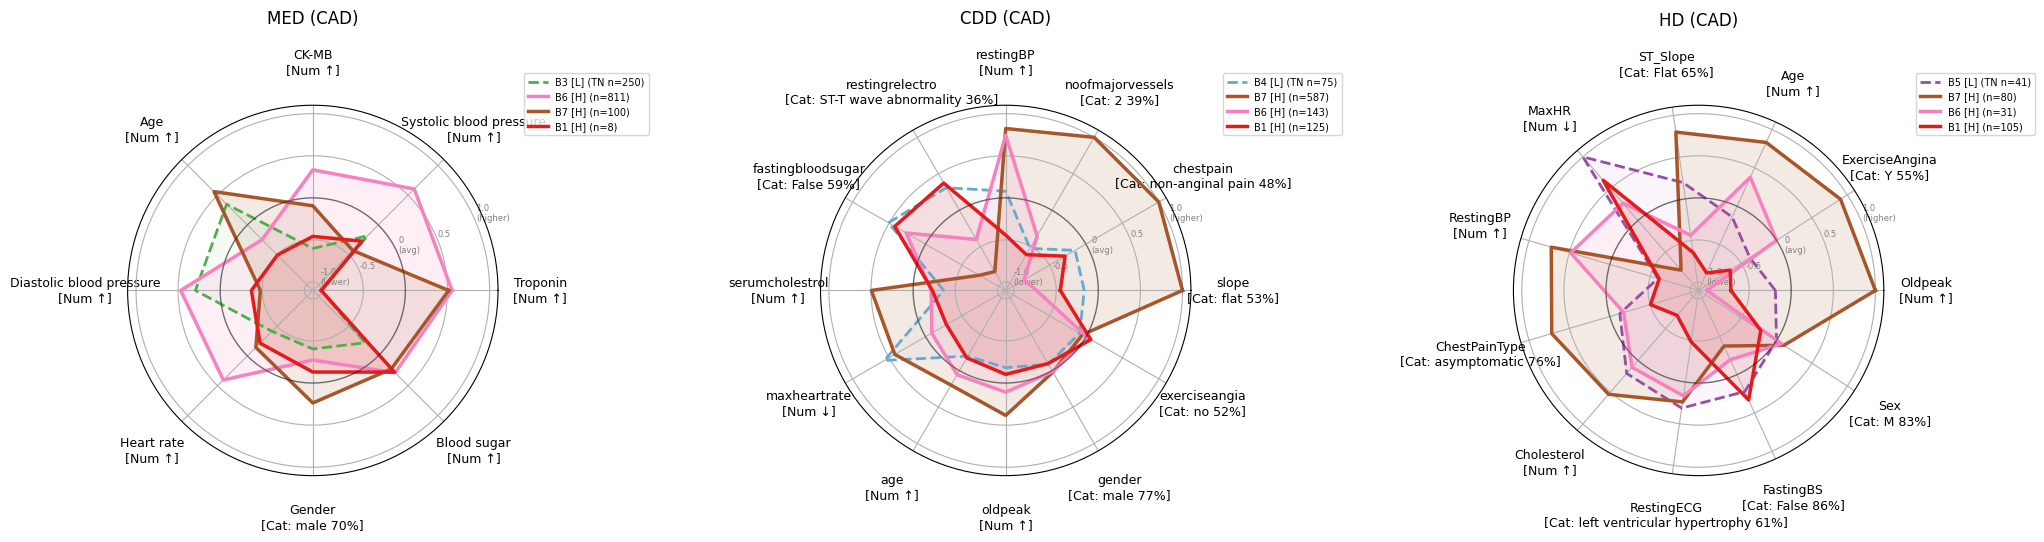

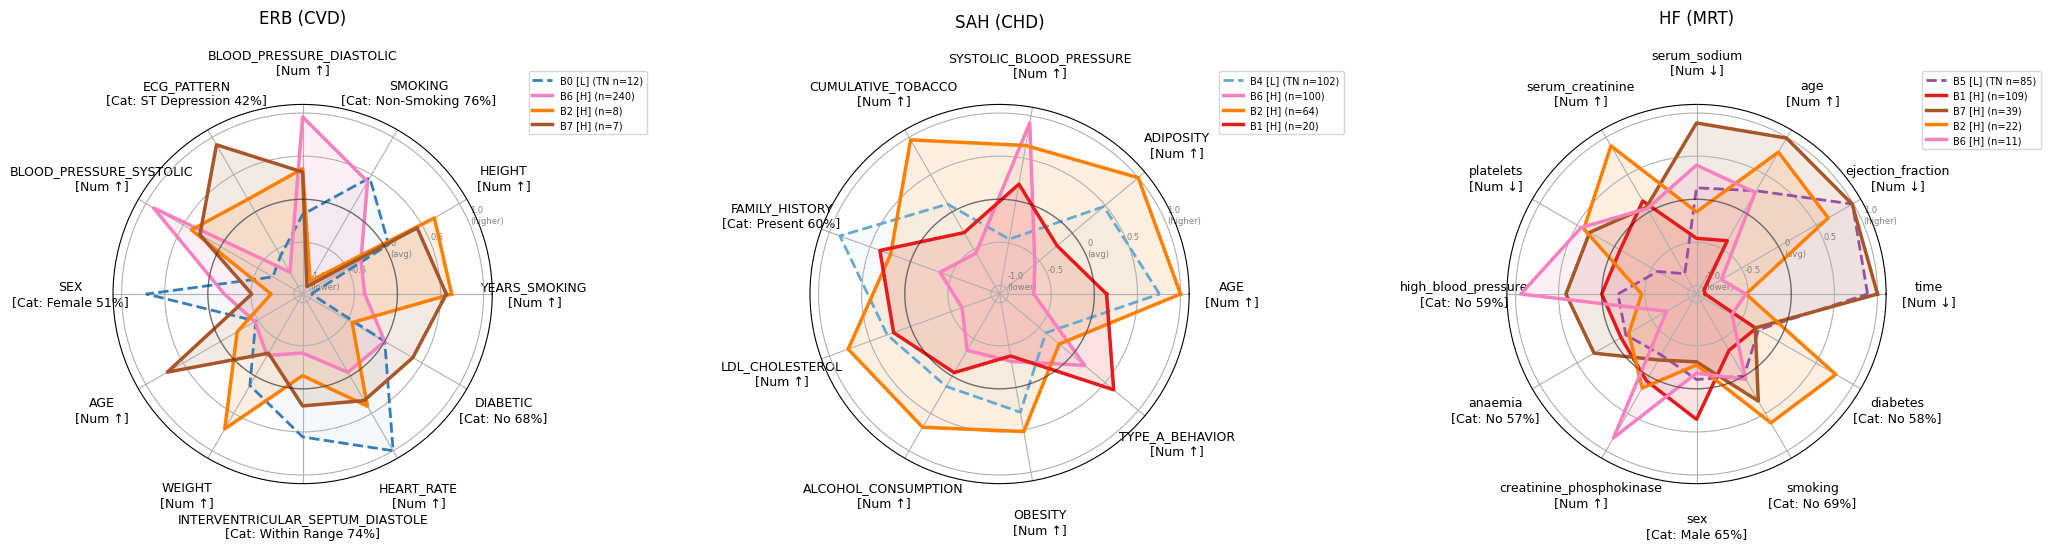

In [96]:
draw_radar_from_data(RADAR_DATA)


Done: ideal_final_part1.png, ideal_final_part2.png
